
# AUTOCTONIA DE RESIDÊNCIA E FONTE PROVÁVEL DE INFECÇÃO


 Este notebook realiza análises agregadas relacionadas
 à autoctonia do caso em relação ao município de residência
 e à fonte provável de infecção registrada no SINAN. Autoctonia significa natural, nativo ou originário do lugar onde vive, se formou ou é encontrado

 ### Interpretação da variável TPAUTOCTO

A variável `TPAUTOCTO` indica se o caso é considerado autóctone do
**município de residência**.

Segundo o dicionário de dados do SINAN:

- **1 — Sim:** o caso é autóctone do município de residência;
- **2 — Não:** o caso não é autóctone do município de residência;
- **3 — Indeterminado:** não foi possível determinar a autoctonia.

Quando `TPAUTOCTO = 1`, os campos referentes à UF, país e município
provável de infecção são preenchidos automaticamente com os respectivos
valores do local de residência.

Quando `TPAUTOCTO = 2`, os campos de provável fonte de infecção podem ser
informados pelo usuário.

Quando `TPAUTOCTO = 3`, os campos referentes ao provável local de infecção
não são preenchidos.

A variável deve, portanto, ser interpretada em conjunto com os campos de
provável fonte de infecção.

Essa regra também muda como devemos pensar o cruzamento futuro entre:
- TPAUTOCTO
- UF_PROVAVEL_INFECCAO
- MUNICIPIO_PROVAVEL_INFECCAO

Por exemplo, quando TPAUTOCTO = Sim, é esperado que:

município provável de infecção = município de residência

e não simplesmente que a UF provável de infecção seja igual à UF de notificação.

Esse ponto é essencial: a referência de TPAUTOCTO é a **residência**, **não a notificação.**

#
# Principais objetivos:
 - analisar se os casos foram classificados como autóctones
   do município de residência;
 - analisar a distribuição dessa classificação por UF;
 - analisar a UF provável de infecção;
 - analisar o município provável de infecção;
 - comparar locais de residência, notificação e provável infecção;
 - avaliar a completude dessas variáveis;
 - produzir artefatos analíticos para etapas posteriores.

**Resumo** da estrutura do notebook:

1. Montagem do Drive
2. Imports
3. Configuração
4. Carregamento do SINAN enriquecido
5. Verificação das variáveis de autoctonia e fonte provável de infecção
6. Autoctonia em relação ao município de residência — Brasil
7. Autoctonia segundo UF de residência
8. UF provável de infecção
9. Comparação UF de residência × UF provável de infecção
10. Município provável de infecção
11. Consistência entre autoctonia e provável local de infecção
12. Completude
13. Visualizações
14. Produtos de autoctonia finais
15. Inventário dos produtos
16. Salvamento
17. Validação dos arquivos

## 1 - Montagem do drive

In [1]:
from google.colab import drive
import os

drive.mount("/content/drive")

Mounted at /content/drive


##2 - Imports

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 3. Configuração

In [3]:
# ============================================================
# CONFIGURAÇÃO
# ============================================================

ANO = 2026

PASTA_BASE = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

PASTA_PROCESSED = (
    PASTA_BASE
    / "data_processed"
    / "SINAN"
    / str(ANO)
)

PASTA_ANALISES = (
    PASTA_BASE
    / "data_analytics"
    / "SINAN"
    / str(ANO)
)

PASTA_ANALISES.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_ENTRADA = (
    PASTA_PROCESSED
    / f"sinan_dengue_{ANO}_enriquecido.parquet"
)

# ============================================================
# DIRETÓRIO DE SAÍDA DOS PRODUTOS autoctonia
# ============================================================

PASTA_SAIDA = (
    PASTA_BASE
    / "data_analytics"
    / "SINAN"
    / str(ANO)
    / "autoctonia"
)

PASTA_SAIDA.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Pasta de saída:\n{PASTA_SAIDA}"
)

print(f"Ano: {ANO}")
print(f"Entrada: {ARQUIVO_ENTRADA}")
print(f"Saída: {PASTA_ANALISES}")

Pasta de saída:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/autoctonia
Ano: 2026
Entrada: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026/sinan_dengue_2026_enriquecido.parquet
Saída: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026


## 4. Carregar o dataframe enriquecido

In [4]:
# ============================================================
# CARREGAMENTO
# ============================================================

df = pd.read_parquet(
    ARQUIVO_ENTRADA
)

print(
    f"Registros carregados: {len(df):,}"
)

print(
    f"Quantidade de variáveis: {df.shape[1]}"
)

display(
    df.head()
)

Registros carregados: 444,266
Quantidade de variáveis: 171


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W,SEMANA_EPIDEMIOLOGICA,ANO_SEM_NOT,UF_NAME,SOROTIPO_ANALITICO,HOSPITALIZ_ANALITICO,EVOLUCAO_ANALITICO,SOROTIPO_DECODED,HOSPITALIZ_DECODED,EVOLUCAO_DECODED,FEBRE_DECODED,MIALGIA_DECODED,CEFALEIA_DECODED,EXANTEMA_DECODED,VOMITO_DECODED,NAUSEA_DECODED,DOR_COSTAS_DECODED,CONJUNTVIT_DECODED,ARTRITE_DECODED,ARTRALGIA_DECODED,PETEQUIA_N_DECODED,LEUCOPENIA_DECODED,LACO_DECODED,DOR_RETRO_DECODED,DIABETES_DECODED,HEMATOLOG_DECODED,HEPATOPAT_DECODED,RENAL_DECODED,HIPERTENSA_DECODED,ACIDO_PEPT_DECODED,AUTO_IMUNE_DECODED,TPAUTOCTO_DECODED,COUFINF_NORMALIZADO,COMUNINF_NORMALIZADO,CODIGO_MUNICIPIO_6,CODIGO_MUNICIPIO_7,MUNICIPIO_NAME,UF_RESIDENCIA,CODIGO_UF_IBGE,REGIAO,POPULACAO_2022,LATITUDE,LONGITUDE,IS_CAPITAL,PIB_PER_CAPITA_2021,COD_MUNICIPIO_PROVAVEL_INFECCAO,MUNICIPIO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO,COD_UF_PROVAVEL_INFECCAO,REGIAO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO_CONSISTENTE
0,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,202619,1978,4048,F,5,1,8,32,320400,32001,1,2026-05-18,251605,1,1,2,1,2,1,1,2,2,1,1,1,2,1,2,2,2,2,2,2,2,None,None,None,0,0,0,None,4,2026-05-18,1,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,1,0,1,1,None,2026-05-25,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-11-08,0,0,0,20,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Não,Sim,Não,Sim,Sim,Não,Não,Sim,Sim,Sim,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320400,3204005,Pancas,ES,32,Sudeste,18893.0,-19.2229,-40.8534,0.0,16755.0,<NA>,None,None,<NA>,None,None
1,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,202601,1984,4041,F,5,4,5,32,320500,32002,1,2026-01-05,0,1,1,1,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,1,2,2,None,None,None,0,0,0,None,4,2026-01-05,2,None,4,None,4,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Sim,Sim,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,202601,1991,4034,F,5,2,6,32,320500,32002,1,2026-01-05,322215,1,2,1,2,1,2,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,None,None,None,0,0,0,None,0,1920-01-05,2,None,4,None,0,0,0,0,2,None,0,0,1,0,0,0,10,2,0,1,1,None,2026-01-20,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,None,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2026-01-05,0,0,0,1,2026,Espírito Santo,<NA>,2,1,None,Não,Cura,Sim,Não,Sim,Não,Sim,Não,Não,Não,Não,Não,Sim,Não,Não,Não,Não,Não,Não,Não,Não,Não,Não,Sim,<NA>,<NA>,320500,3205002,Serra,ES,32,Sudeste,520653.0,-20.1210,-40.3074,0.0,8471034.0,<NA>,None,None,<NA>,None,None
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-

#5. verificação rápida das variáveis essenciais:

In [5]:
# ============================================================
# VARIÁVEIS DE AUTOCTONIA E FONTE PROVÁVEL DE INFECÇÃO
# ============================================================

VARIAVEIS_AUTOCTONIA = [
    "TPAUTOCTO",
    "TPAUTOCTO_DECODED",
    "COUFINF",
    "COUFINF_NORMALIZADO",
    "COMUNINF",
    "COMUNINF_NORMALIZADO",
    "MUNICIPIO_PROVAVEL_INFECCAO",
    "UF_PROVAVEL_INFECCAO",
    "COD_UF_PROVAVEL_INFECCAO",
    "REGIAO_PROVAVEL_INFECCAO",
    "UF_PROVAVEL_INFECCAO_CONSISTENTE",
    "SG_UF_NOT",
    "UF_NAME"
]

In [6]:
# ============================================================
# VERIFICAÇÃO DAS VARIÁVEIS
# ============================================================

for variavel in VARIAVEIS_AUTOCTONIA:

    existe = variavel in df.columns

    print(
        f"{variavel:<40} "
        f"{'OK' if existe else 'NÃO ENCONTRADA'}"
    )

TPAUTOCTO                                OK
TPAUTOCTO_DECODED                        OK
COUFINF                                  OK
COUFINF_NORMALIZADO                      OK
COMUNINF                                 OK
COMUNINF_NORMALIZADO                     OK
MUNICIPIO_PROVAVEL_INFECCAO              OK
UF_PROVAVEL_INFECCAO                     OK
COD_UF_PROVAVEL_INFECCAO                 OK
REGIAO_PROVAVEL_INFECCAO                 OK
UF_PROVAVEL_INFECCAO_CONSISTENTE         OK
SG_UF_NOT                                OK
UF_NAME                                  OK


In [7]:
# ============================================================
# INSPEÇÃO DAS VARIÁVEIS PRINCIPAIS
# ============================================================

display(
    df["TPAUTOCTO_DECODED"]
    .value_counts(
        dropna=False
    )
)

display(
    df["UF_PROVAVEL_INFECCAO"]
    .value_counts(
        dropna=False
    )
    .head(30)
)

display(
    df["MUNICIPIO_PROVAVEL_INFECCAO"]
    .value_counts(
        dropna=False
    )
    .head(30)
)

,count
TPAUTOCTO_DECODED,
Sim,257191
None,163050
Indeterminado,18002
Não,6023


,count
UF_PROVAVEL_INFECCAO,
None,203536
GO,82695
SP,48235
MG,28504
CE,9479
TO,8952
MT,8934
PI,7980
BA,7951


,count
MUNICIPIO_PROVAVEL_INFECCAO,
None,203536
Goiânia,28062
Aparecida de Goiânia,19321
São Paulo,7452
Jataí,6389
Rio Verde,6089
São José do Rio Preto,4637
Araguaína,4437
Taubaté,3988


autoctonia, UF provável de infecção e município provável de infecção não são a mesma coisa.

TPAUTOCTO_DECODED responde se o caso foi classificado como autóctone, não autóctone ou indeterminado. Já UF_PROVAVEL_INFECCAO e MUNICIPIO_PROVAVEL_INFECCAO representam o local atribuído como provável fonte de infecção. Então não devemos inferir automaticamente que um caso é autóctone apenas porque a UF provável de infecção coincide com a UF de notificação.

## 6. Verificação de autoctonia em relação ao município de residência

In [8]:
# ============================================================
# 6 — AUTOCTONIA EM RELAÇÃO AO MUNICÍPIO DE RESIDÊNCIA
# ============================================================

autoctonia_residencia_brasil = (
    df["TPAUTOCTO_DECODED"]
    .fillna("Ausente")
    .value_counts(dropna=False)
    .rename_axis(
        "AUTOCTONE_MUNICIPIO_RESIDENCIA"
    )
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

autoctonia_residencia_brasil[
    "PERCENTUAL_TOTAL"
] = (
    autoctonia_residencia_brasil[
        "TOTAL_REGISTROS"
    ]
    / len(df)
    * 100
).round(2)

display(
    autoctonia_residencia_brasil
)

,AUTOCTONE_MUNICIPIO_RESIDENCIA,TOTAL_REGISTROS,PERCENTUAL_TOTAL
0,Sim,257191,57.89
1,Ausente,163050,36.70
2,Indeterminado,18002,4.05
3,Não,6023,1.36


In [9]:
# ============================================================
# RESUMO DA AUTOCTONIA
# ============================================================

total_registros = len(df)

total_sim = (
    df["TPAUTOCTO_DECODED"]
    .eq("Sim")
    .sum()
)

total_nao = (
    df["TPAUTOCTO_DECODED"]
    .eq("Não")
    .sum()
)

total_indeterminado = (
    df["TPAUTOCTO_DECODED"]
    .eq("Indeterminado")
    .sum()
)

total_ausente = (
    df["TPAUTOCTO_DECODED"]
    .isna()
    .sum()
)

print(
    f"Total de registros: "
    f"{total_registros:,}"
)

print(
    f"Autóctone do município de residência: "
    f"{total_sim:,}"
)

print(
    f"Não autóctone do município de residência: "
    f"{total_nao:,}"
)

print(
    f"Indeterminado: "
    f"{total_indeterminado:,}"
)

print(
    f"Ausente: "
    f"{total_ausente:,}"
)

Total de registros: 444,266
Autóctone do município de residência: 257,191
Não autóctone do município de residência: 6,023
Indeterminado: 18,002
Ausente: 163,050


In [10]:
percentual_sim = (
    total_sim
    / total_registros
    * 100
)

percentual_nao = (
    total_nao
    / total_registros
    * 100
)

percentual_indeterminado = (
    total_indeterminado
    / total_registros
    * 100
)

percentual_ausente = (
    total_ausente
    / total_registros
    * 100
)

print(
    f"Sim: {percentual_sim:.2f}%"
)

print(
    f"Não: {percentual_nao:.2f}%"
)

print(
    f"Indeterminado: "
    f"{percentual_indeterminado:.2f}%"
)

print(
    f"Ausente: "
    f"{percentual_ausente:.2f}%"
)

Sim: 57.89%
Não: 1.36%
Indeterminado: 4.05%
Ausente: 36.70%


Validação

In [11]:
# ============================================================
# VALIDAÇÃO
# ============================================================

total_reconstituido = (
    total_sim
    + total_nao
    + total_indeterminado
    + total_ausente
)

print(
    f"Total original: "
    f"{total_registros:,}"
)

print(
    f"Total reconstituído: "
    f"{total_reconstituido:,}"
)

assert (
    total_reconstituido
    == total_registros
), (
    "A distribuição de TPAUTOCTO "
    "não corresponde ao total de registros."
)

print(
    "OK — distribuição da autoctonia "
    "validada."
)

Total original: 444,266
Total reconstituído: 444,266
OK — distribuição da autoctonia validada.


A interpretação correta dessa tabela deve ser algo como:

“Entre os registros analisados, X% foram classificados como autóctones do município de residência, Y% como não autóctones e Z% como indeterminados.”

Eu evitaria escrever apenas “X% dos casos são autóctones”, porque o campo é especificamente autóctone do município de residência.

## 7 — Autoctonia segundo UF de residência.

In [12]:
# ============================================================
# 7 — AUTOCTONIA SEGUNDO UF DE RESIDÊNCIA
# ============================================================

autoctonia_residencia_uf = (
    df.assign(
        AUTOCTONE_MUNICIPIO_RESIDENCIA=(
            df["TPAUTOCTO_DECODED"]
            .fillna("Ausente")
        )
    )
    .groupby(
        [
            "UF_RESIDENCIA",
            "AUTOCTONE_MUNICIPIO_RESIDENCIA"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

display(
    autoctonia_residencia_uf.sort_values(
        [
            "UF_RESIDENCIA",
            "TOTAL_REGISTROS"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,UF_RESIDENCIA,AUTOCTONE_MUNICIPIO_RESIDENCIA,TOTAL_REGISTROS
0,AC,Ausente,1545
3,AC,Sim,230
1,AC,Indeterminado,29
2,AC,Não,9
4,AL,Ausente,2815
...,...,...,...
106,TO,Não,214
105,TO,Indeterminado,98
110,NaN,Sim,6
108,NaN,Ausente,3


| Situação      | Registros | % dos 1.859 | Interpretação                                                         |
| ------------- | --------: | ----------: | --------------------------------------------------------------------- |
| Ausente       |     1.630 |      87,68% | Não há informação em `TPAUTOCTO`                                      |
| Sim           |       194 |      10,44% | Caso classificado como autóctone do **município onde reside**         |
| Indeterminado |        28 |       1,51% | Não foi possível determinar se é autóctone do município de residência |
| Não           |         7 |       0,38% | Caso classificado como **não autóctone do município onde reside**     |


O que significa Sim?

No Acre:

UF_RESIDENCIA = AC

TPAUTOCTO = Sim

TOTAL = 194


significa que existem 194 registros **de residentes no Acre** para os quais o SINAN informa que o caso é autóctone do município de residência.

**Por exemplo, hipoteticamente:**

Município de residência: Rio Branco - AC

TPAUTOCTO: Sim

indica que o provável local de infecção é o próprio município de residência.

Não significa simplesmente:

“A infecção ocorreu no Acre.”

É mais específico:

“A infecção foi considerada autóctone do município de residência.”

E **Não**?

No Acre:

Não = 7

São sete registros em que o caso **não** foi considerado autóctone do município de residência.

Por exemplo:

Residência:
Rio Branco - AC

TPAUTOCTO:
Não

Provável município de infecção:
**Manaus - AM**

Nesse exemplo hipotético, o caso pertence ao grupo Não.

**Mas há outra possibilidade:**

Residência:
Rio Branco - AC

TPAUTOCTO:
Não

Provável município de infecção:
Cruzeiro do Sul - AC

Também seria Não, embora a provável infecção tenha ocorrido **dentro do próprio Acre.**

Isso demonstra por que não podemos interpretar Não como **“infecção em outra UF”.**

A comparação correta será posteriormente entre:

Município de residência
        ×
Município provável de infecção

Total de registros de cada UF

In [13]:
# ============================================================
# TOTAL DE REGISTROS POR UF DE RESIDÊNCIA
# ============================================================

total_registros_uf_residencia = (
    df.groupby(
        "UF_RESIDENCIA",
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_UF"
    )
)

autoctonia_residencia_uf = (
    autoctonia_residencia_uf.merge(
        total_registros_uf_residencia,
        on="UF_RESIDENCIA",
        how="left"
    )
)

In [14]:
autoctonia_residencia_uf[
    "PERCENTUAL_TOTAL_UF"
] = (
    autoctonia_residencia_uf[
        "TOTAL_REGISTROS"
    ]
    / autoctonia_residencia_uf[
        "TOTAL_UF"
    ]
    * 100
).round(2)

In [15]:
display(
    autoctonia_residencia_uf[
        [
            "UF_RESIDENCIA",
            "AUTOCTONE_MUNICIPIO_RESIDENCIA",
            "TOTAL_REGISTROS",
            "TOTAL_UF",
            "PERCENTUAL_TOTAL_UF"
        ]
    ]
    .sort_values(
        [
            "UF_RESIDENCIA",
            "PERCENTUAL_TOTAL_UF"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,UF_RESIDENCIA,AUTOCTONE_MUNICIPIO_RESIDENCIA,TOTAL_REGISTROS,TOTAL_UF,PERCENTUAL_TOTAL_UF
0,AC,Ausente,1545,1813,85.22
3,AC,Sim,230,1813,12.69
1,AC,Indeterminado,29,1813,1.60
2,AC,Não,9,1813,0.50
4,AL,Ausente,2815,5427,51.87
...,...,...,...,...,...
106,TO,Não,214,15296,1.40
105,TO,Indeterminado,98,15296,0.64
110,NaN,Sim,6,10,60.00
108,NaN,Ausente,3,10,30.00


Isso nos permite responder, por exemplo:

Qual percentual dos registros de residentes de Goiás foi classificado como autóctone do município de residência?

Note que continuamos falando de município, apesar de estarmos agrupando os resultados por UF.

In [16]:
# ============================================================
# RESUMO DA AUTOCTONIA POR UF DE RESIDÊNCIA
# ============================================================

resumo_autoctonia_uf = (
    autoctonia_residencia_uf
    .pivot_table(
        index="UF_RESIDENCIA",
        columns="AUTOCTONE_MUNICIPIO_RESIDENCIA",
        values="TOTAL_REGISTROS",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

In [17]:
for coluna in [
    "Sim",
    "Não",
    "Indeterminado",
    "Ausente"
]:

    if coluna not in resumo_autoctonia_uf.columns:
        resumo_autoctonia_uf[coluna] = 0

In [18]:
resumo_autoctonia_uf = (
    resumo_autoctonia_uf.rename(
        columns={
            "Sim": "AUTOCTONES_RESIDENCIA",
            "Não": "NAO_AUTOCTONES_RESIDENCIA",
            "Indeterminado": "INDETERMINADOS",
            "Ausente": "AUSENTES"
        }
    )
)

In [19]:
resumo_autoctonia_uf[
    "TOTAL_REGISTROS"
] = (
    resumo_autoctonia_uf[
        "AUTOCTONES_RESIDENCIA"
    ]
    + resumo_autoctonia_uf[
        "NAO_AUTOCTONES_RESIDENCIA"
    ]
    + resumo_autoctonia_uf[
        "INDETERMINADOS"
    ]
    + resumo_autoctonia_uf[
        "AUSENTES"
    ]
)

Percentuais por UF

In [20]:
resumo_autoctonia_uf[
    "PERCENTUAL_AUTOCTONES"
] = (
    resumo_autoctonia_uf[
        "AUTOCTONES_RESIDENCIA"
    ]
    / resumo_autoctonia_uf[
        "TOTAL_REGISTROS"
    ]
    * 100
).round(2)

resumo_autoctonia_uf[
    "PERCENTUAL_NAO_AUTOCTONES"
] = (
    resumo_autoctonia_uf[
        "NAO_AUTOCTONES_RESIDENCIA"
    ]
    / resumo_autoctonia_uf[
        "TOTAL_REGISTROS"
    ]
    * 100
).round(2)

resumo_autoctonia_uf[
    "PERCENTUAL_INDETERMINADOS"
] = (
    resumo_autoctonia_uf[
        "INDETERMINADOS"
    ]
    / resumo_autoctonia_uf[
        "TOTAL_REGISTROS"
    ]
    * 100
).round(2)

resumo_autoctonia_uf[
    "PERCENTUAL_AUSENTES"
] = (
    resumo_autoctonia_uf[
        "AUSENTES"
    ]
    / resumo_autoctonia_uf[
        "TOTAL_REGISTROS"
    ]
    * 100
).round(2)

In [21]:
display(
    resumo_autoctonia_uf.sort_values(
        "PERCENTUAL_AUTOCTONES",
        ascending=False
    )
)

AUTOCTONE_MUNICIPIO_RESIDENCIA,UF_RESIDENCIA,AUSENTES,INDETERMINADOS,NAO_AUTOCTONES_RESIDENCIA,AUTOCTONES_RESIDENCIA,TOTAL_REGISTROS,PERCENTUAL_AUTOCTONES,PERCENTUAL_NAO_AUTOCTONES,PERCENTUAL_INDETERMINADOS,PERCENTUAL_AUSENTES
7,ES,79,134,39,18793,19045,98.68,0.20,0.70,0.41
12,MT,2500,112,189,8820,11621,75.90,1.63,0.96,21.51
8,GO,17429,7954,1315,82214,108912,75.49,1.21,7.30,16.00
25,SP,15073,1193,1122,47647,65035,73.26,1.73,1.83,23.18
21,RR,134,53,37,338,562,60.14,6.58,9.43,23.84
26,TO,6095,98,214,8889,15296,58.11,1.40,0.64,39.85
3,AP,218,3,11,278,510,54.51,2.16,0.59,42.75
5,CE,5963,1827,167,9396,17353,54.15,0.96,10.53,34.36
13,PA,4414,105,150,4807,9476,50.73,1.58,1.11,46.58
14,PB,3113,140,47,3230,6530,49.46,0.72,2.14,47.67


Validação

Como Sim, Não, Indeterminado e Ausente são categorias mutuamente exclusivas, a soma deve reconstruir o total da UF:

In [22]:
# ============================================================
# VALIDAÇÃO DA AUTOCTONIA POR UF
# ============================================================

resumo_autoctonia_uf[
    "TOTAL_RECONSTITUIDO"
] = (
    resumo_autoctonia_uf[
        "AUTOCTONES_RESIDENCIA"
    ]
    + resumo_autoctonia_uf[
        "NAO_AUTOCTONES_RESIDENCIA"
    ]
    + resumo_autoctonia_uf[
        "INDETERMINADOS"
    ]
    + resumo_autoctonia_uf[
        "AUSENTES"
    ]
)

resumo_autoctonia_uf[
    "CONSISTENTE"
] = (
    resumo_autoctonia_uf[
        "TOTAL_RECONSTITUIDO"
    ]
    ==
    resumo_autoctonia_uf[
        "TOTAL_REGISTROS"
    ]
)

assert (
    resumo_autoctonia_uf[
        "CONSISTENTE"
    ].all()
), (
    "Existem inconsistências na distribuição "
    "da autoctonia por UF de residência."
)

print(
    "OK — distribuição da autoctonia por "
    "UF de residência validada."
)

OK — distribuição da autoctonia por UF de residência validada.


In [23]:
resumo_autoctonia_uf = (
    resumo_autoctonia_uf.drop(
        columns=[
            "TOTAL_RECONSTITUIDO",
            "CONSISTENTE"
        ]
    )
)

# 8 — UF provável de infecção

Aqui muda o foco: não queremos mais saber se o caso é autóctone do município de residência, mas qual UF foi registrada como provável local de infecção.

Distribuição da UF provável de infecção

In [24]:
# ============================================================
# 8 — UF PROVÁVEL DE INFECÇÃO
# ============================================================

uf_provavel_infeccao = (
    df["UF_PROVAVEL_INFECCAO"]
    .fillna("Ausente")
    .value_counts(dropna=False)
    .rename_axis("UF_PROVAVEL_INFECCAO")
    .reset_index(name="TOTAL_REGISTROS")
)

uf_provavel_infeccao[
    "PERCENTUAL_TOTAL"
] = (
    uf_provavel_infeccao["TOTAL_REGISTROS"]
    / len(df)
    * 100
).round(2)

display(
    uf_provavel_infeccao
    .sort_values(
        "TOTAL_REGISTROS",
        ascending=False
    )
)

,UF_PROVAVEL_INFECCAO,TOTAL_REGISTROS,PERCENTUAL_TOTAL
0,Ausente,203536,45.81
1,GO,82695,18.61
2,SP,48235,10.86
3,MG,28504,6.42
4,CE,9479,2.13
5,TO,8952,2.02
6,MT,8934,2.01
7,PI,7980,1.80
8,BA,7951,1.79
9,MA,6057,1.36


Essa tabela responde:

Considerando todos os registros do SINAN analisados, qual UF aparece como provável local de infecção?

Mas há um cuidado: Ausente não significa necessariamente erro ou desconhecimento. Dependendo de TPAUTOCTO e da classificação do caso, essa ausência pode decorrer das próprias regras de preenchimento.

Quantos possuem UF provável de infecção?

In [25]:
# ============================================================
# RESUMO DO PREENCHIMENTO
# ============================================================

total_registros = len(df)

total_uf_informada = (
    df["UF_PROVAVEL_INFECCAO"]
    .notna()
    .sum()
)

total_uf_ausente = (
    df["UF_PROVAVEL_INFECCAO"]
    .isna()
    .sum()
)

print(
    f"Total de registros: "
    f"{total_registros:,}"
)

print(
    f"UF provável de infecção informada: "
    f"{total_uf_informada:,} "
    f"({total_uf_informada / total_registros * 100:.2f}%)"
)

print(
    f"UF provável de infecção ausente: "
    f"{total_uf_ausente:,} "
    f"({total_uf_ausente / total_registros * 100:.2f}%)"
)

Total de registros: 444,266
UF provável de infecção informada: 240,730 (54.19%)
UF provável de infecção ausente: 203,536 (45.81%)


Cruzar com TPAUTOCTO
Essa análise é particularmente importante por causa da regra no dicionário de dados.

In [26]:
# ============================================================
# UF PROVÁVEL DE INFECÇÃO × AUTOCTONIA
# ============================================================

uf_infeccao_autoctonia = (
    df.assign(
        AUTOCTONIA=(
            df["TPAUTOCTO_DECODED"]
            .fillna("Ausente")
        ),
        STATUS_UF_PROVAVEL_INFECCAO=np.where(
            df["UF_PROVAVEL_INFECCAO"].notna(),
            "Informada",
            "Ausente"
        )
    )
    .groupby(
        [
            "AUTOCTONIA",
            "STATUS_UF_PROVAVEL_INFECCAO"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

display(
    uf_infeccao_autoctonia
)

,AUTOCTONIA,STATUS_UF_PROVAVEL_INFECCAO,TOTAL_REGISTROS
0,Ausente,Ausente,163049
1,Ausente,Informada,1
2,Indeterminado,Ausente,18002
3,Não,Ausente,3391
4,Não,Informada,2632
5,Sim,Ausente,19094
6,Sim,Informada,238097


Segundo a regra do dicionário, temos expectativas diferentes para cada situação.

Para Sim, esperamos que os campos de provável local de infecção sejam preenchidos automaticamente com os dados de residência.

Para Não, esperamos que o provável local de infecção possa ser informado e seja diferente do município de residência.

Para Indeterminado, a ausência dos campos de provável local de infecção é esperada pela regra descrita no dicionário.

Por isso, essa tabela será muito útil no passo de consistência.

Percentual de preenchimento dentro de cada categoria de autoctonia

In [27]:
# ============================================================
# PERCENTUAL DENTRO DE CADA CATEGORIA DE AUTOCTONIA
# ============================================================

total_autoctonia = (
    uf_infeccao_autoctonia
    .groupby(
        "AUTOCTONIA",
        dropna=False
    )["TOTAL_REGISTROS"]
    .sum()
    .reset_index(
        name="TOTAL_AUTOCTONIA"
    )
)

uf_infeccao_autoctonia = (
    uf_infeccao_autoctonia.merge(
        total_autoctonia,
        on="AUTOCTONIA",
        how="left"
    )
)

uf_infeccao_autoctonia[
    "PERCENTUAL_AUTOCTONIA"
] = (
    uf_infeccao_autoctonia[
        "TOTAL_REGISTROS"
    ]
    / uf_infeccao_autoctonia[
        "TOTAL_AUTOCTONIA"
    ]
    * 100
).round(2)

display(
    uf_infeccao_autoctonia
    .sort_values(
        [
            "AUTOCTONIA",
            "STATUS_UF_PROVAVEL_INFECCAO"
        ]
    )
)

,AUTOCTONIA,STATUS_UF_PROVAVEL_INFECCAO,TOTAL_REGISTROS,TOTAL_AUTOCTONIA,PERCENTUAL_AUTOCTONIA
0,Ausente,Ausente,163049,163050,100.00
1,Ausente,Informada,1,163050,0.00
2,Indeterminado,Ausente,18002,18002,100.00
3,Não,Ausente,3391,6023,56.30
4,Não,Informada,2632,6023,43.70
5,Sim,Ausente,19094,257191,7.42
6,Sim,Informada,238097,257191,92.58


Agora podemos responder perguntas mais interessantes, como:

Entre os registros classificados como Sim, qual percentual possui UF provável de infecção preenchida?

ou:

Entre os registros Indeterminado, qual percentual está sem UF provável de infecção?

Distribuição somente entre registros com UF informada

Também vale criar um produto exclusivamente epidemiológico, retirando a ausência do denominador:

In [28]:
# ============================================================
# DISTRIBUIÇÃO ENTRE UFs PROVÁVEIS DE INFECÇÃO INFORMADAS
# ============================================================

uf_provavel_infeccao_informada = (
    df[
        df["UF_PROVAVEL_INFECCAO"]
        .notna()
    ]
    .groupby(
        [
            "COD_UF_PROVAVEL_INFECCAO",
            "UF_PROVAVEL_INFECCAO"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

Calculamos o percentual:

In [29]:
total_com_uf_informada = (
    uf_provavel_infeccao_informada[
        "TOTAL_REGISTROS"
    ]
    .sum()
)

uf_provavel_infeccao_informada[
    "PERCENTUAL_ENTRE_INFORMADOS"
] = (
    uf_provavel_infeccao_informada[
        "TOTAL_REGISTROS"
    ]
    / total_com_uf_informada
    * 100
).round(2)

In [30]:
display(
    uf_provavel_infeccao_informada
    .sort_values(
        "TOTAL_REGISTROS",
        ascending=False
    )
)

,COD_UF_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO,TOTAL_REGISTROS,PERCENTUAL_ENTRE_INFORMADOS
25,52,GO,82695,34.35
19,35,SP,48235,20.04
16,31,MG,28504,11.84
9,23,CE,9479,3.94
6,17,TO,8952,3.72
24,51,MT,8934,3.71
8,22,PI,7980,3.31
15,29,BA,7951,3.30
7,21,MA,6057,2.52
20,41,PR,5477,2.28


52 | GO | 78.851 | 34,87%

significa:

Entre todos os registros que possuem informação sobre a UF provável de infecção, 78.851 (34,87%) indicam Goiás como a UF provável de infecção.

**Não** devemos interpretar essa tabela como:

“34,87% das infecções brasileiras ocorreram em Goiás.”

**Nem como:**

“Goiás foi responsável por 34,87% dos casos de dengue.”

O que os dados permitem afirmar é:

Entre os registros do SINAN analisados que apresentam informação sobre a UF provável de infecção, Goiás foi a UF mais frequentemente registrada como provável local de infecção, representando 34,87% desses registros.

### Interpretação

Entre os registros com informação disponível sobre a UF provável de
infecção, Goiás apresentou a maior frequência, com 78.851 registros
(34,87%), seguido por São Paulo, com 46.555 (20,59%), e Minas Gerais,
com 27.715 (12,26%). Em conjunto, essas três UFs representam 67,72%
dos registros com UF provável de infecção informada.

Esses percentuais devem ser interpretados em relação aos registros
com informação disponível para a variável, e não em relação ao total
de casos de dengue ou à população de cada UF.

Além disso, a UF provável de infecção deve ser analisada em conjunto
com a variável TPAUTOCTO e com o local de residência, pois, segundo
as regras de preenchimento do SINAN, quando o caso é classificado
como autóctone do município de residência, os campos referentes ao
provável local de infecção são preenchidos com as informações do
próprio local de residência.

Validação

In [31]:
# ============================================================
# VALIDAÇÃO — UF PROVÁVEL DE INFECÇÃO
# ============================================================

assert (
    total_uf_informada
    + total_uf_ausente
    ==
    len(df)
), (
    "A soma dos registros com UF informada "
    "e ausente não corresponde ao total."
)

assert (
    uf_provavel_infeccao[
        "TOTAL_REGISTROS"
    ].sum()
    ==
    len(df)
), (
    "A distribuição da UF provável de infecção "
    "não reconstrói o dataset."
)

assert (
    total_com_uf_informada
    ==
    total_uf_informada
), (
    "A distribuição das UFs informadas "
    "apresenta inconsistência."
)

print(
    "OK — distribuição da UF provável "
    "de infecção validada."
)

OK — distribuição da UF provável de infecção validada.


#9— Comparação entre UF de residência e UF provável de infecção.

Esse passo é importante porque começa a mostrar a relação geográfica entre o local de residência e o provável local de infecção. Mas devemos manter uma distinção metodológica: UF igual não é sinônimo de autoctonia, pois TPAUTOCTO se refere ao município de residência, não à UF.

Verificar as variáveis

Primeiro:

In [32]:
# ============================================================
# 9 — UF DE RESIDÊNCIA × UF PROVÁVEL DE INFECÇÃO
# ============================================================

colunas_comparacao = [
    "UF_RESIDENCIA",
    "COD_UF_PROVAVEL_INFECCAO",
    "UF_PROVAVEL_INFECCAO",
    "TPAUTOCTO_DECODED"
]

for coluna in colunas_comparacao:
    print(
        f"{coluna}: "
        f"{'OK' if coluna in df.columns else 'AUSENTE'}"
    )

UF_RESIDENCIA: OK
COD_UF_PROVAVEL_INFECCAO: OK
UF_PROVAVEL_INFECCAO: OK
TPAUTOCTO_DECODED: OK


Selecionar registros comparáveis

Para comparar as UFs, precisamos que ambas estejam disponíveis:

In [33]:
# ============================================================
# REGISTROS COM UF DE RESIDÊNCIA E UF PROVÁVEL INFORMADAS
# ============================================================

df_comparacao_uf = df[
    df["UF_RESIDENCIA"].notna()
    & df["UF_PROVAVEL_INFECCAO"].notna()
].copy()

print(
    f"Total de registros: "
    f"{len(df):,}"
)

print(
    f"Registros comparáveis: "
    f"{len(df_comparacao_uf):,}"
)

print(
    f"Percentual comparável: "
    f"{len(df_comparacao_uf) / len(df) * 100:.2f}%"
)

Total de registros: 444,266
Registros comparáveis: 240,724
Percentual comparável: 54.18%


Esse percentual é importante porque mostra quanto do conjunto realmente permite fazer essa comparação.

Identificar se as UFs são iguais

Como as duas colunas contêm siglas, podemos comparar diretamente:

In [34]:
df_comparacao_uf[
    "MESMA_UF_RESIDENCIA_INFECCAO"
] = np.where(
    df_comparacao_uf["UF_RESIDENCIA"]
    ==
    df_comparacao_uf["UF_PROVAVEL_INFECCAO"],
    "Sim",
    "Não"
)

In [35]:
display(
    df_comparacao_uf[
        [
            "UF_RESIDENCIA",
            "UF_PROVAVEL_INFECCAO",
            "MESMA_UF_RESIDENCIA_INFECCAO",
            "TPAUTOCTO_DECODED"
        ]
    ].head(20)
)

,UF_RESIDENCIA,UF_PROVAVEL_INFECCAO,MESMA_UF_RESIDENCIA_INFECCAO,TPAUTOCTO_DECODED
530,ES,ES,Sim,Não
718,ES,ES,Sim,Não
730,ES,ES,Sim,Não
1060,ES,ES,Sim,Não
1582,ES,ES,Sim,Não
1900,ES,ES,Sim,Não
2113,ES,ES,Sim,Não
2377,ES,ES,Sim,Não
2584,ES,ES,Sim,Não
2830,ES,MG,Não,Não


Atenção à interpretação

MESMA_UF_RESIDENCIA_INFECCAO = Sim significa apenas:

A UF de residência é igual à UF registrada como provável local de infecção.

Não significa necessariamente:

O caso é autóctone do município de residência.

**Por exemplo:**

Residência: Campinas - SP

Provável infecção: Santos - SP

As UFs são iguais (SP = SP), mas os municípios são diferentes.

Resumo nacional da concordância entre UFs

In [36]:
# ============================================================
# RESUMO NACIONAL
# ============================================================

concordancia_uf_residencia_infeccao = (
    df_comparacao_uf[
        "MESMA_UF_RESIDENCIA_INFECCAO"
    ]
    .value_counts()
    .rename_axis("MESMA_UF")
    .reset_index(name="TOTAL_REGISTROS")
)

concordancia_uf_residencia_infeccao[
    "PERCENTUAL_ENTRE_COMPARAVEIS"
] = (
    concordancia_uf_residencia_infeccao[
        "TOTAL_REGISTROS"
    ]
    / len(df_comparacao_uf)
    * 100
).round(2)

display(
    concordancia_uf_residencia_infeccao
)

,MESMA_UF,TOTAL_REGISTROS,PERCENTUAL_ENTRE_COMPARAVEIS
0,Sim,240362,99.85
1,Não,362,0.15


Essa tabela poderá ser interpretada como:

Entre os registros com UF de residência e UF provável de infecção disponíveis, X% apresentam a mesma UF e Y% apresentam UFs diferentes.

Eu usaria “concordância geográfica em nível de UF”, não “autoctonia”.

Criar o fluxo entre UFs

Agora chegamos a uma tabela muito útil para os documentos semânticos:

In [37]:
# ============================================================
# FLUXO UF DE RESIDÊNCIA → UF PROVÁVEL DE INFECÇÃO
# ============================================================

fluxo_uf_residencia_infeccao = (
    df_comparacao_uf
    .groupby(
        [
            "UF_RESIDENCIA",
            "UF_PROVAVEL_INFECCAO"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

Agora calculamos o total de registros comparáveis para cada UF de residência:

In [38]:
total_por_uf_residencia = (
    fluxo_uf_residencia_infeccao
    .groupby(
        "UF_RESIDENCIA"
    )["TOTAL_REGISTROS"]
    .sum()
    .reset_index(
        name="TOTAL_COMPARAVEIS_UF_RESIDENCIA"
    )
)

fluxo_uf_residencia_infeccao = (
    fluxo_uf_residencia_infeccao.merge(
        total_por_uf_residencia,
        on="UF_RESIDENCIA",
        how="left"
    )
)

Calculamos o percentual:

In [39]:
fluxo_uf_residencia_infeccao[
    "PERCENTUAL_DENTRO_UF_RESIDENCIA"
] = (
    fluxo_uf_residencia_infeccao[
        "TOTAL_REGISTROS"
    ]
    / fluxo_uf_residencia_infeccao[
        "TOTAL_COMPARAVEIS_UF_RESIDENCIA"
    ]
    * 100
).round(2)

In [40]:
display(
    fluxo_uf_residencia_infeccao
    .sort_values(
        [
            "UF_RESIDENCIA",
            "TOTAL_REGISTROS"
        ],
        ascending=[
            True,
            False
        ]
    )
)

,UF_RESIDENCIA,UF_PROVAVEL_INFECCAO,TOTAL_REGISTROS,TOTAL_COMPARAVEIS_UF_RESIDENCIA,PERCENTUAL_DENTRO_UF_RESIDENCIA
0,AC,AC,231,231,100.00
1,AL,AL,2399,2400,99.96
2,AL,SE,1,2400,0.04
4,AM,AM,772,778,99.23
5,AM,GO,2,778,0.26
...,...,...,...,...,...
158,TO,TO,8938,8943,99.94
154,TO,GO,2,8943,0.02
155,TO,MA,1,8943,0.01
156,TO,PA,1,8943,0.01


Analisar somente os fluxos interestaduais

Podemos separar os casos em que as UFs são diferentes:

In [41]:
# ============================================================
# FLUXOS ENTRE UFs DIFERENTES
# ============================================================

fluxo_interestadual = (
    fluxo_uf_residencia_infeccao[
        fluxo_uf_residencia_infeccao[
            "UF_RESIDENCIA"
        ]
        !=
        fluxo_uf_residencia_infeccao[
            "UF_PROVAVEL_INFECCAO"
        ]
    ]
    .copy()
)

In [42]:
display(
    fluxo_interestadual
    .sort_values(
        "TOTAL_REGISTROS",
        ascending=False
    )
    .head(30)
)

,UF_RESIDENCIA,UF_PROVAVEL_INFECCAO,TOTAL_REGISTROS,TOTAL_COMPARAVEIS_UF_RESIDENCIA,PERCENTUAL_DENTRO_UF_RESIDENCIA
94,PR,SC,20,5530,0.36
141,SP,MG,17,48280,0.04
95,PR,SP,15,5530,0.27
59,MG,SP,11,28502,0.04
139,SP,GO,11,48280,0.02
136,SP,BA,11,48280,0.02
146,SP,PE,10,48280,0.02
120,RS,SC,9,2013,0.45
149,SP,RJ,7,48280,0.01
20,DF,GO,6,601,1.00


Isso pode revelar relações como:

Residência SP → provável infecção GO

Residência DF → provável infecção GO

Residência MG → provável infecção GO

...

**Mas novamente:** eu chamaria isso de fluxo geográfico registrado entre UF de residência e UF provável de infecção, e não de “casos importados”.

Percentual de provável infecção fora da UF de residência

Também podemos criar uma tabela resumida por UF:

In [43]:
# ============================================================
# CONCORDÂNCIA POR UF DE RESIDÊNCIA
# ============================================================

concordancia_por_uf = (
    df_comparacao_uf
    .groupby(
        [
            "UF_RESIDENCIA",
            "MESMA_UF_RESIDENCIA_INFECCAO"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

for coluna in ["Sim", "Não"]:
    if coluna not in concordancia_por_uf.columns:
        concordancia_por_uf[coluna] = 0

In [44]:
concordancia_por_uf = (
    concordancia_por_uf.rename(
        columns={
            "Sim": "MESMA_UF",
            "Não": "UF_DIFERENTE"
        }
    )
)

concordancia_por_uf[
    "TOTAL_COMPARAVEIS"
] = (
    concordancia_por_uf["MESMA_UF"]
    +
    concordancia_por_uf["UF_DIFERENTE"]
)

In [45]:
concordancia_por_uf[
    "PERCENTUAL_MESMA_UF"
] = (
    concordancia_por_uf["MESMA_UF"]
    / concordancia_por_uf["TOTAL_COMPARAVEIS"]
    * 100
).round(2)

concordancia_por_uf[
    "PERCENTUAL_UF_DIFERENTE"
] = (
    concordancia_por_uf["UF_DIFERENTE"]
    / concordancia_por_uf["TOTAL_COMPARAVEIS"]
    * 100
).round(2)

In [46]:
display(
    concordancia_por_uf
    .sort_values(
        "PERCENTUAL_UF_DIFERENTE",
        ascending=False
    )
)

MESMA_UF_RESIDENCIA_INFECCAO,UF_RESIDENCIA,UF_DIFERENTE,MESMA_UF,TOTAL_COMPARAVEIS,PERCENTUAL_MESMA_UF,PERCENTUAL_UF_DIFERENTE
7,ES,8,36,44,81.82,18.18
23,SC,29,979,1008,97.12,2.88
22,RS,33,1980,2013,98.36,1.64
6,DF,9,592,601,98.50,1.50
17,PR,66,5464,5530,98.81,1.19
21,RR,3,357,360,99.17,0.83
2,AM,6,772,778,99.23,0.77
20,RO,2,446,448,99.55,0.45
18,RJ,8,2238,2246,99.64,0.36
25,SP,91,48189,48280,99.81,0.19


Essa tabela é muito interessante para o RAG porque permitirá responder:

Entre os registros comparáveis de residentes de determinada UF, qual percentual possui outra UF registrada como provável local de infecção?

Cruzar a concordância estadual com TPAUTOCTO

Eu faria ainda uma análise de auditoria:

In [47]:
# ============================================================
# CONCORDÂNCIA ENTRE UFs × TPAUTOCTO
# ============================================================

concordancia_uf_autoctonia = (
    df_comparacao_uf
    .assign(
        AUTOCTONIA=(
            df_comparacao_uf[
                "TPAUTOCTO_DECODED"
            ]
            .fillna("Ausente")
        )
    )
    .groupby(
        [
            "AUTOCTONIA",
            "MESMA_UF_RESIDENCIA_INFECCAO"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

display(
    concordancia_uf_autoctonia
)

,AUTOCTONIA,MESMA_UF_RESIDENCIA_INFECCAO,TOTAL_REGISTROS
0,Ausente,Sim,1
1,Não,Não,360
2,Não,Sim,2271
3,Sim,Não,2
4,Sim,Sim,238090


Aqui temos uma expectativa interessante:

TPAUTOCTO = Sim

        ↓
município provável = município residência

        ↓
consequentemente

        ↓
UF provável = UF residência

**Portanto, se encontrarmos:**

AUTOCTONIA = Sim

MESMA_UF_RESIDENCIA_INFECCAO = Não

isso merece investigação.

Não podemos afirmar automaticamente que é um erro, porque antes precisamos verificar como os campos foram enriquecidos e normalizados. Mas é um excelente candidato a regra de consistência.

Validação

In [48]:
# ============================================================
# VALIDAÇÃO
# ============================================================

assert (
    concordancia_uf_residencia_infeccao[
        "TOTAL_REGISTROS"
    ].sum()
    ==
    len(df_comparacao_uf)
), (
    "A distribuição de concordância "
    "não reconstrói os registros comparáveis."
)

assert (
    fluxo_uf_residencia_infeccao[
        "TOTAL_REGISTROS"
    ].sum()
    ==
    len(df_comparacao_uf)
), (
    "O fluxo entre UFs não reconstrói "
    "os registros comparáveis."
)

assert (
    concordancia_por_uf[
        "TOTAL_COMPARAVEIS"
    ].sum()
    ==
    len(df_comparacao_uf)
), (
    "O resumo por UF não reconstrói "
    "os registros comparáveis."
)

print(
    "OK — comparação entre UF de residência "
    "e UF provável de infecção validada."
)

OK — comparação entre UF de residência e UF provável de infecção validada.


## 10 — Município de residência × município provável de infecção

Este passo é especialmente importante porque agora estamos trabalhando exatamente no nível territorial definido pelo TPAUTOCTO: o município de residência.

A ideia é verificar onde temos informação suficiente para comparar os dois municípios, construir os fluxos registrados e, depois, confrontar essa comparação com TPAUTOCTO.

Verificar as variáveis

In [49]:
# ============================================================
# 10 — MUNICÍPIO DE RESIDÊNCIA × MUNICÍPIO PROVÁVEL DE INFECÇÃO
# ============================================================

colunas_municipio = [
    "CODIGO_MUNICIPIO_6",
    "MUNICIPIO_NAME",
    "UF_RESIDENCIA",
    "COMUNINF_NORMALIZADO",
    "MUNICIPIO_PROVAVEL_INFECCAO",
    "UF_PROVAVEL_INFECCAO",
    "TPAUTOCTO_DECODED"
]

for coluna in colunas_municipio:
    print(
        f"{coluna}: "
        f"{'OK' if coluna in df.columns else 'AUSENTE'}"
    )

CODIGO_MUNICIPIO_6: OK
MUNICIPIO_NAME: OK
UF_RESIDENCIA: OK
COMUNINF_NORMALIZADO: OK
MUNICIPIO_PROVAVEL_INFECCAO: OK
UF_PROVAVEL_INFECCAO: OK
TPAUTOCTO_DECODED: OK


In [50]:
display(
    df[
        colunas_municipio
    ].head(20)
)

,CODIGO_MUNICIPIO_6,MUNICIPIO_NAME,UF_RESIDENCIA,COMUNINF_NORMALIZADO,MUNICIPIO_PROVAVEL_INFECCAO,UF_PROVAVEL_INFECCAO,TPAUTOCTO_DECODED
0,320400,Pancas,ES,<NA>,None,None,Sim
1,320500,Serra,ES,<NA>,None,None,Sim
2,320500,Serra,ES,<NA>,None,None,Sim
3,320500,Serra,ES,<NA>,None,None,Sim
4,320530,Vitória,ES,<NA>,None,None,Sim
5,320520,Vila Velha,ES,<NA>,None,None,Sim
6,320530,Vitória,ES,<NA>,None,None,Sim
7,320520,Vila Velha,ES,<NA>,None,None,Sim
8,320520,Vila Velha,ES,<NA>,None,None,Indeterminado
9,320150,Colatina,ES,<NA>,None,None,Sim


Normalizar os códigos para comparação

Essa etapa é importante. Não devemos comparar os municípios pelos nomes, pois diferenças de acentuação, grafia etc. poderiam gerar falsos resultados.

Vamos comparar os códigos IBGE de 6 dígitos:

In [51]:
# ============================================================
# NORMALIZAÇÃO DOS CÓDIGOS MUNICIPAIS
# ============================================================

df["COD_MUN_RESIDENCIA_COMPARACAO"] = (
    df["CODIGO_MUNICIPIO_6"]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
    .str.zfill(6)
)

df["COD_MUN_INFECCAO_COMPARACAO"] = (
    df["COMUNINF_NORMALIZADO"]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
    .str.zfill(6)
)

In [52]:
display(
    df[
        [
            "CODIGO_MUNICIPIO_6",
            "COD_MUN_RESIDENCIA_COMPARACAO",
            "COMUNINF_NORMALIZADO",
            "COD_MUN_INFECCAO_COMPARACAO"
        ]
    ].head(20)
)

,CODIGO_MUNICIPIO_6,COD_MUN_RESIDENCIA_COMPARACAO,COMUNINF_NORMALIZADO,COD_MUN_INFECCAO_COMPARACAO
0,320400,320400,<NA>,<NA>
1,320500,320500,<NA>,<NA>
2,320500,320500,<NA>,<NA>
3,320500,320500,<NA>,<NA>
4,320530,320530,<NA>,<NA>
5,320520,320520,<NA>,<NA>
6,320530,320530,<NA>,<NA>
7,320520,320520,<NA>,<NA>
8,320520,320520,<NA>,<NA>
9,320150,320150,<NA>,<NA>


Selecionar apenas registros comparáveis

Para determinar se os municípios são iguais, precisamos dos dois códigos:

In [53]:
# ============================================================
# REGISTROS COM OS DOIS MUNICÍPIOS DISPONÍVEIS
# ============================================================

df_comparacao_municipio = df[
    df["COD_MUN_RESIDENCIA_COMPARACAO"].notna()
    &
    df["COD_MUN_INFECCAO_COMPARACAO"].notna()
].copy()

print(
    f"Total de registros: "
    f"{len(df):,}"
)

print(
    f"Registros comparáveis: "
    f"{len(df_comparacao_municipio):,}"
)

print(
    f"Percentual comparável: "
    f"{len(df_comparacao_municipio) / len(df) * 100:.2f}%"
)

Total de registros: 444,266
Registros comparáveis: 240,724
Percentual comparável: 54.18%


Comparar os municípios

Agora podemos fazer a comparação diretamente:

In [54]:
df_comparacao_municipio[
    "MESMO_MUNICIPIO_RESIDENCIA_INFECCAO"
] = np.where(
    df_comparacao_municipio[
        "COD_MUN_RESIDENCIA_COMPARACAO"
    ]
    ==
    df_comparacao_municipio[
        "COD_MUN_INFECCAO_COMPARACAO"
    ],
    "Sim",
    "Não"
)

In [55]:
display(
    df_comparacao_municipio[
        [
            "UF_RESIDENCIA",
            "MUNICIPIO_NAME",
            "UF_PROVAVEL_INFECCAO",
            "MUNICIPIO_PROVAVEL_INFECCAO",
            "MESMO_MUNICIPIO_RESIDENCIA_INFECCAO",
            "TPAUTOCTO_DECODED"
        ]
    ].head(30)
)

,UF_RESIDENCIA,MUNICIPIO_NAME,UF_PROVAVEL_INFECCAO,MUNICIPIO_PROVAVEL_INFECCAO,MESMO_MUNICIPIO_RESIDENCIA_INFECCAO,TPAUTOCTO_DECODED
530,ES,Itarana,ES,Guarapari,Não,Não
718,ES,Jerônimo Monteiro,ES,Itapemirim,Não,Não
730,ES,Santa Maria de Jetibá,ES,Baixo Guandu,Não,Não
1060,ES,Alfredo Chaves,ES,Piúma,Não,Não
1582,ES,Anchieta,ES,Itapemirim,Não,Não
1900,ES,Anchieta,ES,Itapemirim,Não,Não
2113,ES,Apiacá,ES,Apiacá,Sim,Não
2377,ES,Domingos Martins,ES,Viana,Não,Não
2584,ES,Itarana,ES,Laranja da Terra,Não,Não
2830,ES,Ecoporanga,MG,Aimorés,Não,Não


Agora temos algo muito mais próximo semanticamente do TPAUTOCTO.

Se:

TPAUTOCTO = Sim

a regra do SINAN indica que o caso é autóctone do município de residência. Portanto, esperamos:

MUNICIPIO_RESIDENCIA = MUNICIPIO_PROVAVEL_INFECCAO

**Resumo nacional**

In [56]:
# ============================================================
# CONCORDÂNCIA ENTRE OS MUNICÍPIOS — BRASIL
# ============================================================

concordancia_municipio_residencia_infeccao = (
    df_comparacao_municipio[
        "MESMO_MUNICIPIO_RESIDENCIA_INFECCAO"
    ]
    .value_counts()
    .rename_axis("MESMO_MUNICIPIO")
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

concordancia_municipio_residencia_infeccao[
    "PERCENTUAL_ENTRE_COMPARAVEIS"
] = (
    concordancia_municipio_residencia_infeccao[
        "TOTAL_REGISTROS"
    ]
    / len(df_comparacao_municipio)
    * 100
).round(2)

display(
    concordancia_municipio_residencia_infeccao
)

,MESMO_MUNICIPIO,TOTAL_REGISTROS,PERCENTUAL_ENTRE_COMPARAVEIS
0,Sim,239212,99.37
1,Não,1512,0.63


A interpretação será:

Entre os registros com município de residência e município provável de infecção disponíveis, X% apresentam o mesmo município e Y% apresentam municípios diferentes.

Aqui, entretanto, ainda não chamaria X% de “percentual de casos autóctones”. Temos uma comparação geográfica calculada, enquanto TPAUTOCTO é a classificação oficial registrada.

Cruzamento com TPAUTOCTO

Esta é provavelmente a análise mais interessante deste passo:

In [57]:
# ============================================================
# TPAUTOCTO × CONCORDÂNCIA DOS MUNICÍPIOS
# ============================================================

autoctonia_concordancia_municipio = (
    df_comparacao_municipio
    .assign(
        AUTOCTONIA=(
            df_comparacao_municipio[
                "TPAUTOCTO_DECODED"
            ]
            .fillna("Ausente")
        )
    )
    .groupby(
        [
            "AUTOCTONIA",
            "MESMO_MUNICIPIO_RESIDENCIA_INFECCAO"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

display(
    autoctonia_concordancia_municipio
)

,AUTOCTONIA,MESMO_MUNICIPIO_RESIDENCIA_INFECCAO,TOTAL_REGISTROS
0,Ausente,Sim,1
1,Não,Não,1504
2,Não,Sim,1127
3,Sim,Não,8
4,Sim,Sim,238084


In [58]:
total_por_autoctonia = (
    autoctonia_concordancia_municipio
    .groupby(
        "AUTOCTONIA"
    )["TOTAL_REGISTROS"]
    .sum()
    .reset_index(
        name="TOTAL_AUTOCTONIA"
    )
)

autoctonia_concordancia_municipio = (
    autoctonia_concordancia_municipio.merge(
        total_por_autoctonia,
        on="AUTOCTONIA",
        how="left"
    )
)

autoctonia_concordancia_municipio[
    "PERCENTUAL_AUTOCTONIA"
] = (
    autoctonia_concordancia_municipio[
        "TOTAL_REGISTROS"
    ]
    / autoctonia_concordancia_municipio[
        "TOTAL_AUTOCTONIA"
    ]
    * 100
).round(2)

display(
    autoctonia_concordancia_municipio
)

,AUTOCTONIA,MESMO_MUNICIPIO_RESIDENCIA_INFECCAO,TOTAL_REGISTROS,TOTAL_AUTOCTONIA,PERCENTUAL_AUTOCTONIA
0,Ausente,Sim,1,1,100.00
1,Não,Não,1504,2631,57.16
2,Não,Sim,1127,2631,42.84
3,Sim,Não,8,238092,0.00
4,Sim,Sim,238084,238092,100.00


Como interpretar?

A situação:

TPAUTOCTO = Sim

Mesmo município = Sim

é compatível com a regra do SINAN.

Já:

TPAUTOCTO = Sim

Mesmo município = Não

é uma potencial inconsistência e merece investigação.


Por outro lado:

TPAUTOCTO = Não

Mesmo município = Não

é a situação esperada.

E:

TPAUTOCTO = Não

Mesmo município = Sim

também merece investigação.

Isso nos aproxima bastante de uma verdadeira regra de **consistência semântica.**

Identificar os registros potencialmente inconsistentes

Não vamos alterar nem excluir esses registros. Apenas identificá-los para análise:

In [59]:
# ============================================================
# POTENCIAIS INCONSISTÊNCIAS
# ============================================================

mask_inconsistencia_autoctonia = (
    (
        df_comparacao_municipio[
            "TPAUTOCTO_DECODED"
        ].eq("Sim")
        &
        df_comparacao_municipio[
            "MESMO_MUNICIPIO_RESIDENCIA_INFECCAO"
        ].eq("Não")
    )
    |
    (
        df_comparacao_municipio[
            "TPAUTOCTO_DECODED"
        ].eq("Não")
        &
        df_comparacao_municipio[
            "MESMO_MUNICIPIO_RESIDENCIA_INFECCAO"
        ].eq("Sim")
    )
)

df_inconsistencias_autoctonia = (
    df_comparacao_municipio[
        mask_inconsistencia_autoctonia
    ]
    .copy()
)

print(
    f"Potenciais inconsistências: "
    f"{len(df_inconsistencias_autoctonia):,}"
)

Potenciais inconsistências: 1,135


In [60]:
display(
    df_inconsistencias_autoctonia[
        [
            "TPAUTOCTO_DECODED",
            "UF_RESIDENCIA",
            "MUNICIPIO_NAME",
            "COD_MUN_RESIDENCIA_COMPARACAO",
            "UF_PROVAVEL_INFECCAO",
            "MUNICIPIO_PROVAVEL_INFECCAO",
            "COD_MUN_INFECCAO_COMPARACAO",
            "MESMO_MUNICIPIO_RESIDENCIA_INFECCAO"
        ]
    ].head(30)
)

,TPAUTOCTO_DECODED,UF_RESIDENCIA,MUNICIPIO_NAME,COD_MUN_RESIDENCIA_COMPARACAO,UF_PROVAVEL_INFECCAO,MUNICIPIO_PROVAVEL_INFECCAO,COD_MUN_INFECCAO_COMPARACAO,MESMO_MUNICIPIO_RESIDENCIA_INFECCAO
2113,Não,ES,Apiacá,320050,ES,Apiacá,320050,Sim
4625,Não,ES,Cachoeiro de Itapemirim,320120,ES,Cachoeiro de Itapemirim,320120,Sim
4950,Não,ES,Alfredo Chaves,320030,ES,Alfredo Chaves,320030,Sim
6296,Não,ES,Serra,320500,ES,Serra,320500,Sim
7768,Não,MG,São Gonçalo do Rio Preto,312550,MG,São Gonçalo do Rio Preto,312550,Sim
13154,Não,ES,Serra,320500,ES,Serra,320500,Sim
14168,Não,ES,Itaguaçu,320270,ES,Itaguaçu,320270,Sim
16214,Não,ES,Serra,320500,ES,Serra,320500,Sim
16844,Não,ES,Serra,320500,ES,Serra,320500,Sim
18408,Não,ES,Cachoeiro de Itapemirim,320120,ES,Cachoeiro de Itapemirim,320120,Sim


Fluxo entre municípios

Também podemos produzir o agregado completo:

In [61]:
# ============================================================
# FLUXO MUNICÍPIO DE RESIDÊNCIA → PROVÁVEL MUNICÍPIO DE INFECÇÃO
# ============================================================

fluxo_municipio_residencia_infeccao = (
    df_comparacao_municipio
    .groupby(
        [
            "UF_RESIDENCIA",
            "MUNICIPIO_NAME",
            "COD_MUN_RESIDENCIA_COMPARACAO",
            "UF_PROVAVEL_INFECCAO",
            "MUNICIPIO_PROVAVEL_INFECCAO",
            "COD_MUN_INFECCAO_COMPARACAO"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

display(
    fluxo_municipio_residencia_infeccao
    .sort_values(
        "TOTAL_REGISTROS",
        ascending=False
    )
    .head(30)
)

,UF_RESIDENCIA,MUNICIPIO_NAME,COD_MUN_RESIDENCIA_COMPARACAO,UF_PROVAVEL_INFECCAO,MUNICIPIO_PROVAVEL_INFECCAO,COD_MUN_INFECCAO_COMPARACAO,TOTAL_REGISTROS
774,GO,Goiânia,520870,GO,Goiânia,520870,28000
672,GO,Aparecida de Goiânia,520140,GO,Aparecida de Goiânia,520140,19314
4497,SP,São Paulo,355030,SP,São Paulo,355030,7405
833,GO,Jataí,521190,GO,Jataí,521190,6385
946,GO,Rio Verde,521880,GO,Rio Verde,521880,6071
4461,SP,São José do Rio Preto,354980,SP,São José do Rio Preto,354980,4629
4599,TO,Araguaína,170210,TO,Araguaína,170210,4428
4532,SP,Taubaté,355410,SP,Taubaté,355410,3979
2714,PI,Teresina,221100,PI,Teresina,221100,3971
3822,SP,Campinas,350950,SP,Campinas,350950,3749


Esse produto pode ser bastante valioso para o RAG, porque preserva relações como:

município de residência

        ↓
provável município de infecção

        ↓
quantidade de registros

Validação

In [62]:
# ============================================================
# VALIDAÇÃO
# ============================================================

assert (
    concordancia_municipio_residencia_infeccao[
        "TOTAL_REGISTROS"
    ].sum()
    ==
    len(df_comparacao_municipio)
), (
    "A concordância municipal não reconstrói "
    "os registros comparáveis."
)

assert (
    fluxo_municipio_residencia_infeccao[
        "TOTAL_REGISTROS"
    ].sum()
    ==
    len(df_comparacao_municipio)
), (
    "O fluxo municipal não reconstrói "
    "os registros comparáveis."
)

print(
    "OK — comparação entre município de residência "
    "e município provável de infecção validada."
)

OK — comparação entre município de residência e município provável de infecção validada.


## 11 — Consistência entre autoctonia e provável local de infecção.

Esse passo é diferente dos anteriores: agora não estamos apenas fazendo análise epidemiológica. Estamos verificando se os valores registrados são compatíveis com as regras descritas no dicionário do SINAN.

Eu faria isso sem modificar o DataFrame original e classificaria cada registro como Consistente, Inconsistente ou Não avaliável.

Definir formalmente a regra

Com base no dicionário de dados do SINAN:

TPAUTOCTO = Sim

- caso autóctone do município de residência

- município provável de infecção deve corresponder ao município de residência

TPAUTOCTO = Não

- caso não autóctone do município de residência

- município provável de infecção deve ser diferente do município de residência

TPAUTOCTO = Indeterminado

- campos do provável local de infecção não são preenchidos

TPAUTOCTO ausente

- não é possível avaliar essa regra apenas com TPAUTOCTO

Criar uma base específica para a validação

In [63]:
# ============================================================
# 11 — CONSISTÊNCIA ENTRE AUTOCTONIA E LOCAL DE INFECÇÃO
# ============================================================

df_consistencia_autoctonia = df.copy()

In [64]:
colunas_validacao = [
    "TPAUTOCTO_DECODED",
    "COD_MUN_RESIDENCIA_COMPARACAO",
    "COD_MUN_INFECCAO_COMPARACAO"
]

for coluna in colunas_validacao:
    print(
        f"{coluna}: "
        f"{'OK' if coluna in df_consistencia_autoctonia.columns else 'AUSENTE'}"
    )

TPAUTOCTO_DECODED: OK
COD_MUN_RESIDENCIA_COMPARACAO: OK
COD_MUN_INFECCAO_COMPARACAO: OK


Criar indicadores auxiliares

Primeiro identificamos se os municípios estão disponíveis:

In [65]:
df_consistencia_autoctonia[
    "MUNICIPIO_RESIDENCIA_INFORMADO"
] = (
    df_consistencia_autoctonia[
        "COD_MUN_RESIDENCIA_COMPARACAO"
    ].notna()
)

df_consistencia_autoctonia[
    "MUNICIPIO_INFECCAO_INFORMADO"
] = (
    df_consistencia_autoctonia[
        "COD_MUN_INFECCAO_COMPARACAO"
    ].notna()
)

Depois verificamos a igualdade:




In [66]:
df_consistencia_autoctonia[
    "MESMO_MUNICIPIO"
] = (
    df_consistencia_autoctonia[
        "COD_MUN_RESIDENCIA_COMPARACAO"
    ]
    ==
    df_consistencia_autoctonia[
        "COD_MUN_INFECCAO_COMPARACAO"
    ]
)

Mas atenção: se algum município estiver ausente, não devemos interpretar False como “municípios diferentes”.

Por isso, essa comparação só será usada quando os dois códigos estiverem disponíveis.

Regra para TPAUTOCTO = Sim

Para Sim, temos:

residência informada + provável município informado + municípios iguais = Consistente

Criamos as máscaras:

In [67]:
mask_sim = (
    df_consistencia_autoctonia[
        "TPAUTOCTO_DECODED"
    ].eq("Sim")
)

mask_sim_avaliavel = (
    mask_sim
    &
    df_consistencia_autoctonia[
        "MUNICIPIO_RESIDENCIA_INFORMADO"
    ]
    &
    df_consistencia_autoctonia[
        "MUNICIPIO_INFECCAO_INFORMADO"
    ]
)

mask_sim_consistente = (
    mask_sim_avaliavel
    &
    df_consistencia_autoctonia[
        "MESMO_MUNICIPIO"
    ]
)

mask_sim_inconsistente = (
    mask_sim_avaliavel
    &
    ~df_consistencia_autoctonia[
        "MESMO_MUNICIPIO"
    ]
)

Assim:

TPAUTOCTO = Sim

Residência = Goiânia

Infecção   = Goiânia
→ Consistente

enquanto:

TPAUTOCTO = Sim

Residência = Goiânia

Infecção   = Anápolis
→ Inconsistente

**Regra para TPAUTOCTO = Não**

Aqui ocorre o contrário.

In [68]:
mask_nao = (
    df_consistencia_autoctonia[
        "TPAUTOCTO_DECODED"
    ].eq("Não")
)

mask_nao_avaliavel = (
    mask_nao
    &
    df_consistencia_autoctonia[
        "MUNICIPIO_RESIDENCIA_INFORMADO"
    ]
    &
    df_consistencia_autoctonia[
        "MUNICIPIO_INFECCAO_INFORMADO"
    ]
)

mask_nao_consistente = (
    mask_nao_avaliavel
    &
    ~df_consistencia_autoctonia[
        "MESMO_MUNICIPIO"
    ]
)

mask_nao_inconsistente = (
    mask_nao_avaliavel
    &
    df_consistencia_autoctonia[
        "MESMO_MUNICIPIO"
    ]
)

Portanto:

TPAUTOCTO = Não

Residência = Goiânia

Infecção   = Brasília
→ Consistente

e:

TPAUTOCTO = Não

Residência = Goiânia

Infecção   = Goiânia
→ Inconsistente

**Regra para Indeterminado**

Aqui precisamos ser um pouco mais cuidadosos.

O dicionário diz que, quando:

TPAUTOCTO = 3 — Indeterminado

os campos de provável local de infecção devem ser pulados.

Portanto, a situação esperada é não haver município provável de infecção.

In [69]:
mask_indeterminado = (
    df_consistencia_autoctonia[
        "TPAUTOCTO_DECODED"
    ].eq("Indeterminado")
)

mask_indeterminado_consistente = (
    mask_indeterminado
    &
    ~df_consistencia_autoctonia[
        "MUNICIPIO_INFECCAO_INFORMADO"
    ]
)

mask_indeterminado_inconsistente = (
    mask_indeterminado
    &
    df_consistencia_autoctonia[
        "MUNICIPIO_INFECCAO_INFORMADO"
    ]
)

Nesse caso, estamos verificando outra regra:

Indeterminado + município provável ausente
→ compatível com a regra

Indeterminado + município provável preenchido
→ potencialmente incompatível com a regra

Eu ainda usaria cautela com a palavra “inconsistente”, pois estamos validando um arquivo exportado e pode haver particularidades históricas do sistema.

Consolidar a classificação

Inicialmente todos ficam como Não avaliável:

In [70]:
df_consistencia_autoctonia[
    "STATUS_CONSISTENCIA_AUTOCTONIA"
] = "Não avaliável"

Aplicamos os consistentes:

In [71]:
mask_consistente = (
    mask_sim_consistente
    |
    mask_nao_consistente
    |
    mask_indeterminado_consistente
)

df_consistencia_autoctonia.loc[
    mask_consistente,
    "STATUS_CONSISTENCIA_AUTOCTONIA"
] = "Consistente"

E os inconsistentes:

In [72]:
mask_inconsistente = (
    mask_sim_inconsistente
    |
    mask_nao_inconsistente
    |
    mask_indeterminado_inconsistente
)

df_consistencia_autoctonia.loc[
    mask_inconsistente,
    "STATUS_CONSISTENCIA_AUTOCTONIA"
] = "Inconsistente"

Agora:

In [73]:
display(
    df_consistencia_autoctonia[
        "STATUS_CONSISTENCIA_AUTOCTONIA"
    ]
    .value_counts(
        dropna=False
    )
)

,count
STATUS_CONSISTENCIA_AUTOCTONIA,
Consistente,257590
Não avaliável,185541
Inconsistente,1135


**Criar o relatório agregado**

In [74]:
relatorio_consistencia_autoctonia = (
    df_consistencia_autoctonia[
        "STATUS_CONSISTENCIA_AUTOCTONIA"
    ]
    .value_counts()
    .rename_axis(
        "STATUS"
    )
    .reset_index(
        name="TOTAL_REGISTROS"
    )
)

relatorio_consistencia_autoctonia[
    "PERCENTUAL_TOTAL"
] = (
    relatorio_consistencia_autoctonia[
        "TOTAL_REGISTROS"
    ]
    / len(df_consistencia_autoctonia)
    * 100
).round(2)

display(
    relatorio_consistencia_autoctonia
)

,STATUS,TOTAL_REGISTROS,PERCENTUAL_TOTAL
0,Consistente,257590,57.98
1,Não avaliável,185541,41.76
2,Inconsistente,1135,0.26


Precisamos calcular também a consistência entre os avaliáveis.

Percentual de consistência entre avaliáveis

In [75]:
total_consistentes = (
    df_consistencia_autoctonia[
        "STATUS_CONSISTENCIA_AUTOCTONIA"
    ]
    .eq("Consistente")
    .sum()
)

total_inconsistentes = (
    df_consistencia_autoctonia[
        "STATUS_CONSISTENCIA_AUTOCTONIA"
    ]
    .eq("Inconsistente")
    .sum()
)

total_nao_avaliaveis = (
    df_consistencia_autoctonia[
        "STATUS_CONSISTENCIA_AUTOCTONIA"
    ]
    .eq("Não avaliável")
    .sum()
)

total_avaliaveis = (
    total_consistentes
    +
    total_inconsistentes
)

percentual_consistencia = (
    total_consistentes
    / total_avaliaveis
    * 100
    if total_avaliaveis > 0
    else np.nan
)

percentual_inconsistencia = (
    total_inconsistentes
    / total_avaliaveis
    * 100
    if total_avaliaveis > 0
    else np.nan
)

In [76]:
print("=" * 60)
print("CONSISTÊNCIA DA AUTOCTONIA")
print("=" * 60)

print(
    f"Total de registros: "
    f"{len(df_consistencia_autoctonia):,}"
)

print(
    f"Avaliáveis: "
    f"{total_avaliaveis:,}"
)

print(
    f"Consistentes: "
    f"{total_consistentes:,}"
)

print(
    f"Inconsistentes: "
    f"{total_inconsistentes:,}"
)

print(
    f"Não avaliáveis: "
    f"{total_nao_avaliaveis:,}"
)

print()

print(
    f"Consistência entre avaliáveis: "
    f"{percentual_consistencia:.2f}%"
)

print(
    f"Inconsistência entre avaliáveis: "
    f"{percentual_inconsistencia:.2f}%"
)

CONSISTÊNCIA DA AUTOCTONIA
Total de registros: 444,266
Avaliáveis: 258,725
Consistentes: 257,590
Inconsistentes: 1,135
Não avaliáveis: 185,541

Consistência entre avaliáveis: 99.56%
Inconsistência entre avaliáveis: 0.44%


Esse denominador é metodologicamente melhor:

Consistência= [Consistentes/ (Consistentes+Inconsistentes)] × 100

Identificar o motivo da consistência/inconsistência

Eu acrescentaria isso porque será muito útil posteriormente para sua ontologia e para gerar explicações.

In [77]:
df_consistencia_autoctonia[
    "REGRA_CONSISTENCIA_AUTOCTONIA"
] = "Não avaliável"

In [78]:
df_consistencia_autoctonia.loc[
    mask_sim_consistente,
    "REGRA_CONSISTENCIA_AUTOCTONIA"
] = (
    "Autóctone e município de infecção "
    "igual ao município de residência"
)

df_consistencia_autoctonia.loc[
    mask_sim_inconsistente,
    "REGRA_CONSISTENCIA_AUTOCTONIA"
] = (
    "Autóctone, mas município de infecção "
    "diferente do município de residência"
)

df_consistencia_autoctonia.loc[
    mask_nao_consistente,
    "REGRA_CONSISTENCIA_AUTOCTONIA"
] = (
    "Não autóctone e município de infecção "
    "diferente do município de residência"
)

df_consistencia_autoctonia.loc[
    mask_nao_inconsistente,
    "REGRA_CONSISTENCIA_AUTOCTONIA"
] = (
    "Não autóctone, mas município de infecção "
    "igual ao município de residência"
)

df_consistencia_autoctonia.loc[
    mask_indeterminado_consistente,
    "REGRA_CONSISTENCIA_AUTOCTONIA"
] = (
    "Autoctonia indeterminada e município "
    "provável de infecção ausente"
)

df_consistencia_autoctonia.loc[
    mask_indeterminado_inconsistente,
    "REGRA_CONSISTENCIA_AUTOCTONIA"
] = (
    "Autoctonia indeterminada, mas município "
    "provável de infecção informado"
)

Agora podemos produzir uma tabela extremamente informativa:

In [79]:
detalhamento_consistencia_autoctonia = (
    df_consistencia_autoctonia
    .groupby(
        [
            "STATUS_CONSISTENCIA_AUTOCTONIA",
            "REGRA_CONSISTENCIA_AUTOCTONIA"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="TOTAL_REGISTROS"
    )
    .sort_values(
        [
            "STATUS_CONSISTENCIA_AUTOCTONIA",
            "TOTAL_REGISTROS"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    detalhamento_consistencia_autoctonia
)

,STATUS_CONSISTENCIA_AUTOCTONIA,REGRA_CONSISTENCIA_AUTOCTONIA,TOTAL_REGISTROS
1,Consistente,Autóctone e município de infecção igual ao mun...,238084
0,Consistente,Autoctonia indeterminada e município provável ...,18002
2,Consistente,Não autóctone e município de infecção diferent...,1504
4,Inconsistente,"Não autóctone, mas município de infecção igual...",1127
3,Inconsistente,"Autóctone, mas município de infecção diferente...",8
5,Não avaliável,Não avaliável,185541


**Trabalhos futuros:**

Um cuidado metodológico importante

Eu considero este passo uma validação semântica baseada nas regras do dicionário de dados, mas ainda não a chamaria de validação completa de TPAUTOCTO.

Ainda falta incorporar a regra de aplicabilidade relacionada à classificação final do caso. Isso é importante principalmente para interpretar TPAUTOCTO ausente.

Portanto, neste momento:

TPAUTOCTO ausente
→ Não avaliável

e não:

TPAUTOCTO ausente
→ Inconsistente

Isso evita penalizar registros nos quais o campo nem deveria estar preenchido.

E há uma conexão direta com sua tese: essa mesma regra que estamos implementando proceduralmente em Pandas é uma excelente candidata a ser posteriormente formalizada em SHACL, enquanto a ontologia fornece o significado dos conceitos envolvidos. Assim você poderá comparar a validação tabular do pipeline com a validação semântica dos dados transformados.

O próximo passo, antes das visualizações, deveria ser o 12 — Completude e aplicabilidade das variáveis de autoctonia e provável fonte de infecção, onde podemos finalmente separar ausente, não aplicável e ausente quando deveria estar preenchido. Para isso, precisaremos olhar exatamente qual coluna do seu DataFrame representa o campo 62 — classificação final.

#12 - Visualizações

Autoctonia do município de residência — Brasil

Aqui faz sentido mostrar Sim, Não, Indeterminado e Ausente, pois queremos visualizar a composição de TPAUTOCTO.

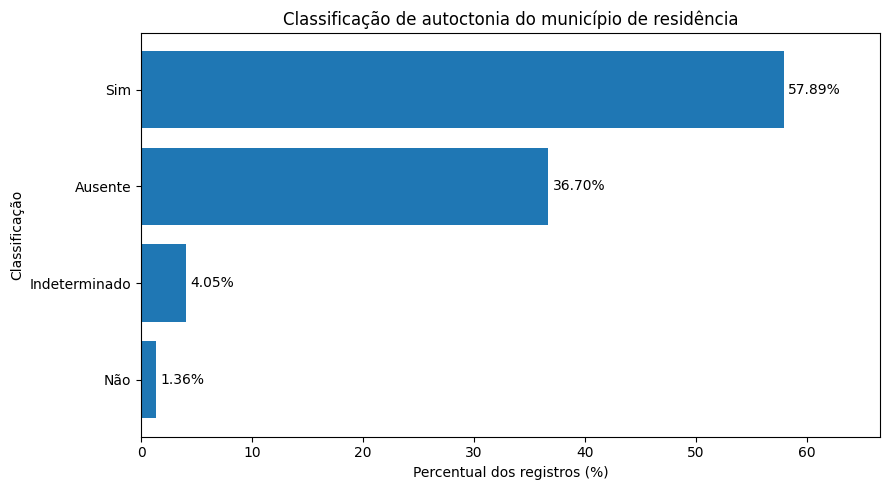

In [80]:
import matplotlib.pyplot as plt

# ============================================================
# 12.1 — AUTOCTONIA DO MUNICÍPIO DE RESIDÊNCIA — BRASIL
# ============================================================

dados_grafico = (
    autoctonia_residencia_brasil
    .sort_values(
        "PERCENTUAL_TOTAL",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

barras = ax.barh(
    dados_grafico[
        "AUTOCTONE_MUNICIPIO_RESIDENCIA"
    ],
    dados_grafico[
        "PERCENTUAL_TOTAL"
    ]
)

ax.bar_label(
    barras,
    fmt="%.2f%%",
    padding=3
)

ax.set_title(
    "Classificação de autoctonia do município de residência"
)

ax.set_xlabel(
    "Percentual dos registros (%)"
)

ax.set_ylabel(
    "Classificação"
)

ax.set_xlim(
    0,
    dados_grafico["PERCENTUAL_TOTAL"].max() * 1.15
)

plt.tight_layout()
plt.show()

### Interpretação

O gráfico apresenta a distribuição dos registros segundo a variável
`TPAUTOCTO`, que indica se o caso foi classificado como autóctone do
município de residência.

A categoria **Sim** representa os registros classificados como autóctones
do município de residência; **Não** indica que o provável local de infecção
é diferente do município de residência; **Indeterminado** corresponde aos
casos em que não foi possível determinar a autoctonia; e **Ausente**
representa os registros sem informação para essa variável.

Os percentuais são calculados em relação ao total de registros analisados.
A presença de valores ausentes deve ser interpretada considerando as regras
de aplicabilidade do campo definidas pelo SINAN.

## Percentual de casos classificados como autóctones por UF de residência

Para comparar as UFs:

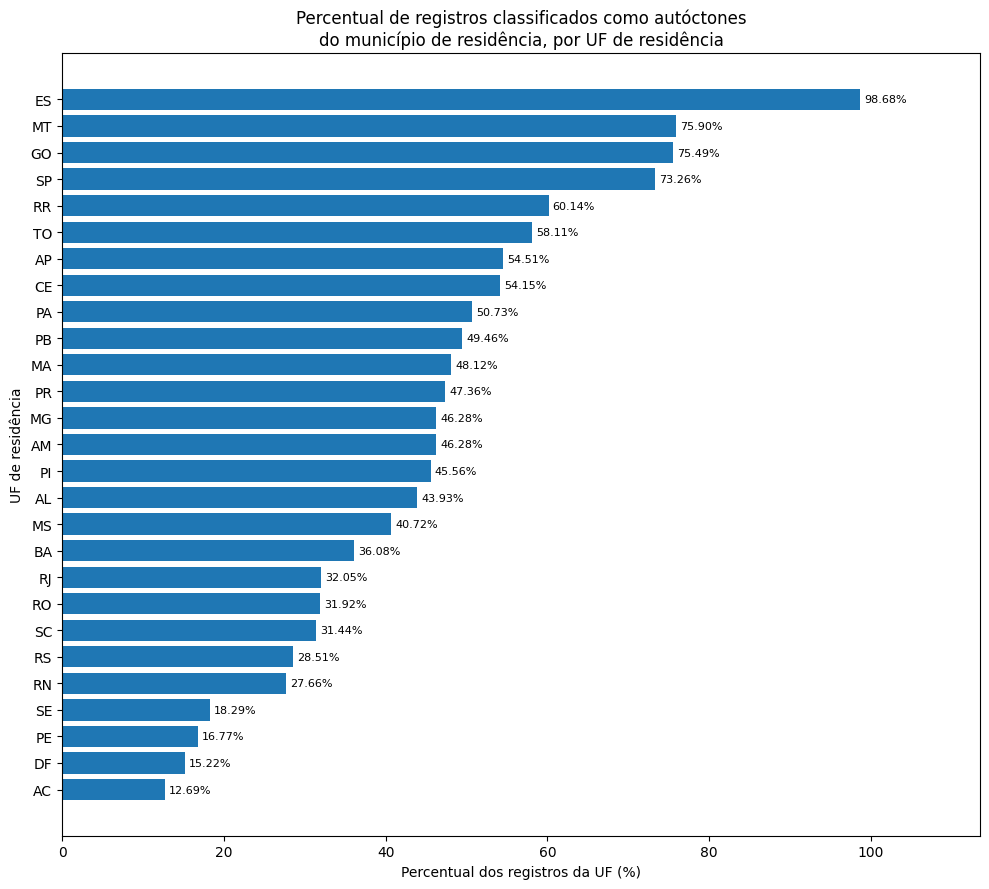

In [81]:
# ============================================================
# 12.2 — AUTOCTONIA POR UF DE RESIDÊNCIA
# ============================================================

dados_grafico = (
    resumo_autoctonia_uf[
        resumo_autoctonia_uf[
            "UF_RESIDENCIA"
        ].notna()
    ]
    .sort_values(
        "PERCENTUAL_AUTOCTONES",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 9)
)

barras = ax.barh(
    dados_grafico[
        "UF_RESIDENCIA"
    ],
    dados_grafico[
        "PERCENTUAL_AUTOCTONES"
    ]
)

ax.bar_label(
    barras,
    fmt="%.2f%%",
    padding=3,
    fontsize=8
)

ax.set_title(
    "Percentual de registros classificados como autóctones\n"
    "do município de residência, por UF de residência"
)

ax.set_xlabel(
    "Percentual dos registros da UF (%)"
)

ax.set_ylabel(
    "UF de residência"
)

ax.set_xlim(
    0,
    max(
        1,
        dados_grafico[
            "PERCENTUAL_AUTOCTONES"
        ].max() * 1.15
    )
)

plt.tight_layout()
plt.show()

Há uma ressalva importante nesse gráfico: o denominador ainda é todos os registros daquela UF, incluindo Indeterminado e Ausente.

Então o título precisa continuar dizendo “percentual de registros classificados como autóctones”, e não “taxa de autoctonia”.

### Interpretação

O gráfico compara as UFs segundo o percentual de registros classificados
como autóctones do município de residência (`TPAUTOCTO = Sim`).

A UF apresentada corresponde à **UF de residência** do caso. Portanto,
o gráfico não indica que o caso seja simplesmente autóctone da UF, mas
que foi classificado como autóctone do seu município de residência.

O percentual utiliza como denominador o total de registros de cada UF,
incluindo registros com classificação indeterminada ou ausente. Por esse
motivo, os valores devem ser interpretados como a proporção de registros
da UF classificados como autóctones, e não como uma taxa epidemiológica
de autoctonia.

## UFs prováveis de infecção

Esse é um dos gráficos mais úteis do notebook:

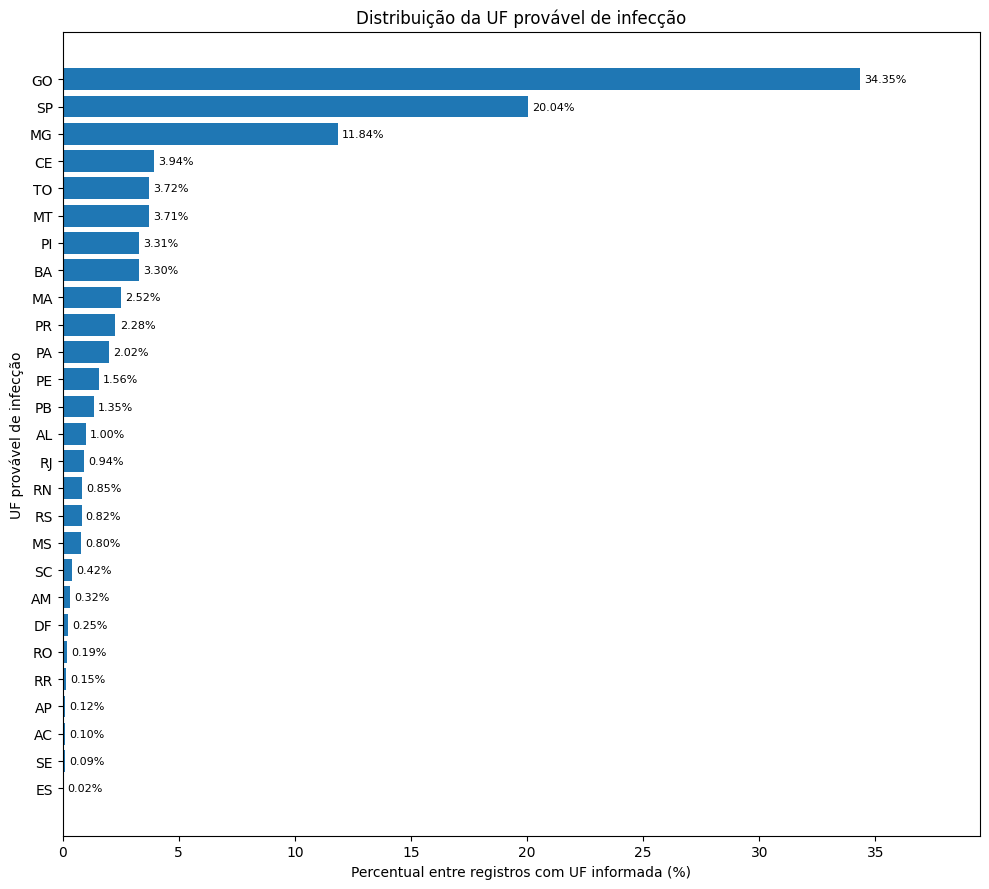

In [82]:
# ============================================================
# 12.3 — UF PROVÁVEL DE INFECÇÃO
# ============================================================

dados_grafico = (
    uf_provavel_infeccao_informada
    .sort_values(
        "PERCENTUAL_ENTRE_INFORMADOS",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(10, 9)
)

barras = ax.barh(
    dados_grafico[
        "UF_PROVAVEL_INFECCAO"
    ],
    dados_grafico[
        "PERCENTUAL_ENTRE_INFORMADOS"
    ]
)

ax.bar_label(
    barras,
    fmt="%.2f%%",
    padding=3,
    fontsize=8
)

ax.set_title(
    "Distribuição da UF provável de infecção"
)

ax.set_xlabel(
    "Percentual entre registros com UF informada (%)"
)

ax.set_ylabel(
    "UF provável de infecção"
)

ax.set_xlim(
    0,
    dados_grafico[
        "PERCENTUAL_ENTRE_INFORMADOS"
    ].max() * 1.15
)

plt.tight_layout()
plt.show()

Esse gráfico vai deixar visualmente muito evidente a concentração que você encontrou em Goiás, São Paulo e Minas Gerais.

**Nota:** os percentuais consideram apenas os registros com UF provável
de infecção informada. A UF provável de infecção não deve ser interpretada
isoladamente como local de ocorrência de todos os casos, pois seu
preenchimento está relacionado às regras de autoctonia e ao local de
residência registrado no SINAN.



### Interpretação

O gráfico apresenta a distribuição das UFs registradas como provável
local de infecção. O percentual é calculado somente entre os registros
que possuem informação disponível sobre a UF provável de infecção.

Assim, uma maior participação de determinada UF indica que ela aparece
com maior frequência como provável UF de infecção entre os registros
com essa informação disponível.

Essa distribuição não deve ser interpretada como incidência, risco ou
participação da UF no total nacional de casos de dengue. Além disso,
a informação deve ser analisada em conjunto com a autoctonia e o local
de residência, pois o preenchimento do provável local de infecção está
relacionado às regras de preenchimento do SINAN.

## Mesma UF de residência e provável infecção

Agora podemos mostrar a concordância geográfica estadual:

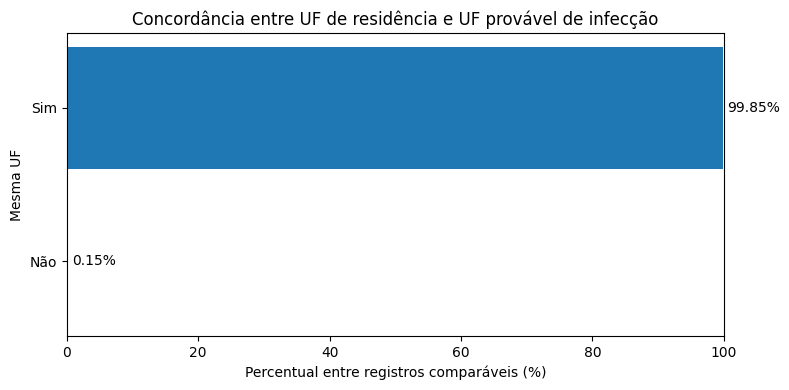

In [83]:
# ============================================================
# 12.4 — UF DE RESIDÊNCIA × UF PROVÁVEL DE INFECÇÃO
# ============================================================

dados_grafico = (
    concordancia_uf_residencia_infeccao
    .sort_values(
        "PERCENTUAL_ENTRE_COMPARAVEIS",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(8, 4)
)

barras = ax.barh(
    dados_grafico["MESMA_UF"],
    dados_grafico[
        "PERCENTUAL_ENTRE_COMPARAVEIS"
    ]
)

ax.bar_label(
    barras,
    fmt="%.2f%%",
    padding=3
)

ax.set_title(
    "Concordância entre UF de residência "
    "e UF provável de infecção"
)

ax.set_xlabel(
    "Percentual entre registros comparáveis (%)"
)

ax.set_ylabel(
    "Mesma UF"
)

ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

Aqui Sim significa somente:

UF de residência = UF provável de infecção.

Não significa necessariamente autoctonia do município.

### Interpretação do gráfico acima

O gráfico mostra a concordância geográfica entre a UF de residência e
a UF registrada como provável local de infecção, considerando apenas
os registros em que ambas as informações estão disponíveis.

A categoria **Sim** indica que a UF de residência e a provável UF de
infecção são iguais, enquanto **Não** indica que são diferentes.

A igualdade entre as UFs não deve ser interpretada diretamente como
autoctonia, pois a variável `TPAUTOCTO` define a autoctonia em relação
ao **município de residência**. Um caso pode apresentar a mesma UF de
residência e de provável infecção, mas municípios diferentes.

Mesmo município de residência e provável infecção

Este é ainda mais interessante, porque trabalha no mesmo nível territorial de TPAUTOCTO.

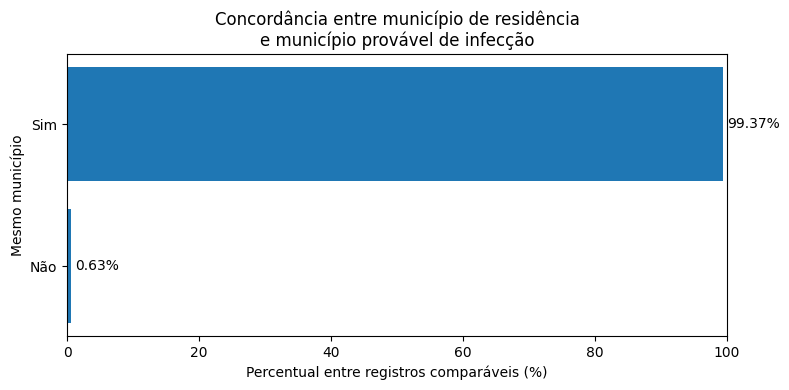

In [84]:
# ============================================================
# 12.5 — MUNICÍPIO DE RESIDÊNCIA × PROVÁVEL MUNICÍPIO
# ============================================================

dados_grafico = (
    concordancia_municipio_residencia_infeccao
    .sort_values(
        "PERCENTUAL_ENTRE_COMPARAVEIS",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(8, 4)
)

barras = ax.barh(
    dados_grafico[
        "MESMO_MUNICIPIO"
    ],
    dados_grafico[
        "PERCENTUAL_ENTRE_COMPARAVEIS"
    ]
)

ax.bar_label(
    barras,
    fmt="%.2f%%",
    padding=3
)

ax.set_title(
    "Concordância entre município de residência\n"
    "e município provável de infecção"
)

ax.set_xlabel(
    "Percentual entre registros comparáveis (%)"
)

ax.set_ylabel(
    "Mesmo município"
)

ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

Esse gráfico é descritivo da concordância territorial calculada. Ainda não devemos chamá-lo diretamente de gráfico de autoctonia.

### Interpretação do gráfico acima

O gráfico apresenta a concordância entre o município de residência e
o município registrado como provável local de infecção, considerando
somente os registros em que ambos os municípios puderam ser comparados.

A categoria **Sim** indica que os dois municípios são iguais, enquanto
**Não** indica que são diferentes.

Essa comparação está diretamente relacionada ao nível territorial
utilizado pela variável `TPAUTOCTO`. Entretanto, o resultado representa
uma concordância geográfica calculada a partir dos campos disponíveis
e não substitui a classificação de autoctonia registrada originalmente
no SINAN.

Consistência da regra de autoctonia

Por fim, um gráfico do resultado do passo 11:

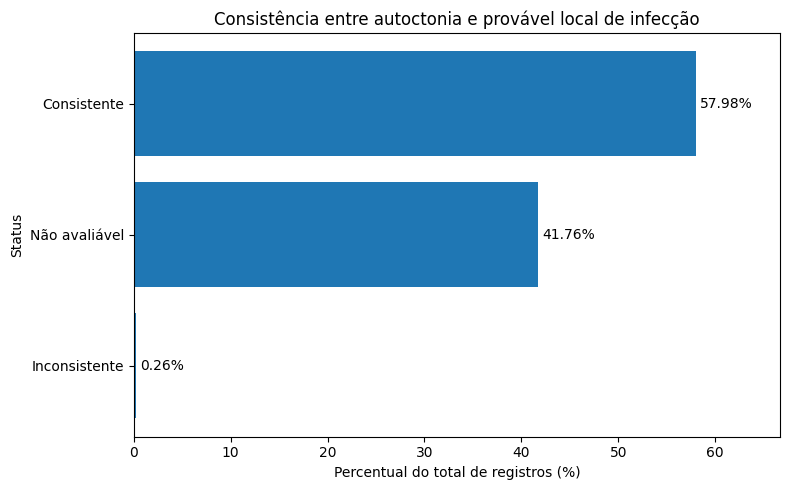

In [85]:
# ============================================================
# 12.6 — CONSISTÊNCIA DA AUTOCTONIA
# ============================================================

dados_grafico = (
    relatorio_consistencia_autoctonia
    .sort_values(
        "PERCENTUAL_TOTAL",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

barras = ax.barh(
    dados_grafico[
        "STATUS"
    ],
    dados_grafico[
        "PERCENTUAL_TOTAL"
    ]
)

ax.bar_label(
    barras,
    fmt="%.2f%%",
    padding=3
)

ax.set_title(
    "Consistência entre autoctonia e "
    "provável local de infecção"
)

ax.set_xlabel(
    "Percentual do total de registros (%)"
)

ax.set_ylabel(
    "Status"
)

ax.set_xlim(
    0,
    dados_grafico[
        "PERCENTUAL_TOTAL"
    ].max() * 1.15
)

plt.tight_layout()
plt.show()

### Interpretação do gráfico acima

O gráfico apresenta a consistência entre a classificação de autoctonia
registrada no SINAN e a relação observada entre o município de residência
e o município provável de infecção.

Um registro é considerado consistente quando:

- `TPAUTOCTO = Sim` e os municípios de residência e provável infecção
  são iguais; ou
- `TPAUTOCTO = Não` e os municípios são diferentes.

A análise também considera a regra associada aos registros classificados
como `Indeterminado`, para os quais se espera ausência do provável
município de infecção.

Os percentuais de consistência e inconsistência são calculados somente
entre os registros avaliáveis para as regras implementadas. Registros
sem informação suficiente para aplicação das regras não participam
desse denominador.

Os resultados representam uma verificação de consistência baseada nas
regras de preenchimento descritas no dicionário de dados do SINAN.

Entretanto, para avaliação da regra, considero mais importante mostrar somente os registros avaliáveis:

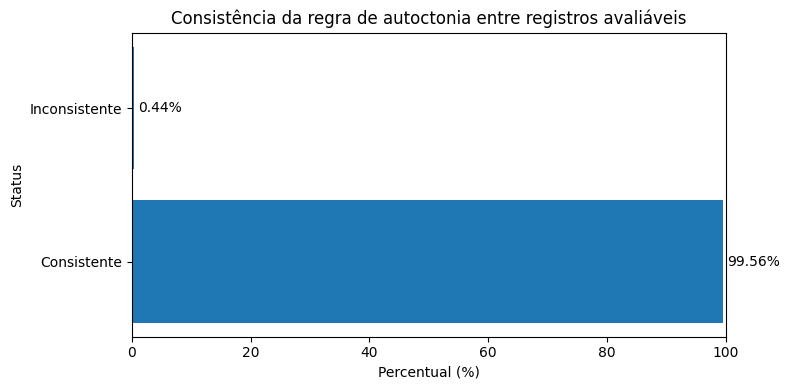

In [86]:
# ============================================================
# CONSISTÊNCIA ENTRE REGISTROS AVALIÁVEIS
# ============================================================

consistencia_avaliaveis = pd.DataFrame({
    "STATUS": [
        "Consistente",
        "Inconsistente"
    ],
    "PERCENTUAL": [
        percentual_consistencia,
        percentual_inconsistencia
    ]
})

fig, ax = plt.subplots(
    figsize=(8, 4)
)

barras = ax.barh(
    consistencia_avaliaveis[
        "STATUS"
    ],
    consistencia_avaliaveis[
        "PERCENTUAL"
    ]
)

ax.bar_label(
    barras,
    fmt="%.2f%%",
    padding=3
)

ax.set_title(
    "Consistência da regra de autoctonia "
    "entre registros avaliáveis"
)

ax.set_xlabel(
    "Percentual (%)"
)

ax.set_ylabel(
    "Status"
)

ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

Esse segundo gráfico é metodologicamente melhor para comunicar a consistência da regra, pois o denominador é:

$$ \text{Consistentes}+\text{Inconsistentes} $$

e não todo o banco.

Essa validação verifica a compatibilidade entre os valores registrados
e as regras implementadas no pipeline, não constituindo, por si só,
uma validação da veracidade epidemiológica do provável local de infecção.

##13 — Produtos finais de autoctonia e fonte provável de infecção.


In [87]:
# ============================================================
# 13 — PRODUTOS FINAIS DE AUTOCTONIA E FONTE DE INFECÇÃO
# ============================================================

produtos_esperados = [
    "autoctonia_residencia_brasil",
    "resumo_autoctonia_uf",
    "uf_provavel_infeccao",
    "uf_provavel_infeccao_informada",
    "uf_infeccao_autoctonia",
    "concordancia_uf_residencia_infeccao",
    "fluxo_uf_residencia_infeccao",
    "concordancia_por_uf",
    "concordancia_municipio_residencia_infeccao",
    "autoctonia_concordancia_municipio",
    "fluxo_municipio_residencia_infeccao",
    "relatorio_consistencia_autoctonia",
    "detalhamento_consistencia_autoctonia"
]

for produto in produtos_esperados:

    if produto in globals():
        print(
            f"OK      {produto}"
        )
    else:
        print(
            f"AUSENTE {produto}"
        )

OK      autoctonia_residencia_brasil
OK      resumo_autoctonia_uf
OK      uf_provavel_infeccao
OK      uf_provavel_infeccao_informada
OK      uf_infeccao_autoctonia
OK      concordancia_uf_residencia_infeccao
OK      fluxo_uf_residencia_infeccao
OK      concordancia_por_uf
OK      concordancia_municipio_residencia_infeccao
OK      autoctonia_concordancia_municipio
OK      fluxo_municipio_residencia_infeccao
OK      relatorio_consistencia_autoctonia
OK      detalhamento_consistencia_autoctonia


## Criar o dicionário final

Seguindo o padrão dos notebooks anteriores:

In [88]:
# ============================================================
# PRODUTOS ANALÍTICOS FINAIS
# ============================================================

PRODUTOS_AUTOCTONIA = {

    # Autoctonia
    "autoctonia_residencia_brasil":
        autoctonia_residencia_brasil,

    "autoctonia_residencia_uf":
        resumo_autoctonia_uf,

    # Fonte provável de infecção
    "uf_provavel_infeccao":
        uf_provavel_infeccao,

    "uf_provavel_infeccao_informada":
        uf_provavel_infeccao_informada,

    "uf_infeccao_autoctonia":
        uf_infeccao_autoctonia,

    # Relações geográficas
    "concordancia_uf_residencia_infeccao":
        concordancia_uf_residencia_infeccao,

    "fluxo_uf_residencia_infeccao":
        fluxo_uf_residencia_infeccao,

    "concordancia_por_uf":
        concordancia_por_uf,

    "concordancia_municipio_residencia_infeccao":
        concordancia_municipio_residencia_infeccao,

    "autoctonia_concordancia_municipio":
        autoctonia_concordancia_municipio,

    "fluxo_municipio_residencia_infeccao":
        fluxo_municipio_residencia_infeccao,

    # Consistência
    "consistencia_autoctonia":
        relatorio_consistencia_autoctonia,

    "detalhamento_consistencia_autoctonia":
        detalhamento_consistencia_autoctonia
}

In [89]:
print(
    f"Total de produtos finais: "
    f"{len(PRODUTOS_AUTOCTONIA)}"
)

Total de produtos finais: 13


Descrever cada produto

Como fizemos nos notebooks anteriores, eu criaria um dicionário de descrições:

In [90]:
# ============================================================
# DESCRIÇÃO DOS PRODUTOS
# ============================================================

DESCRICAO_PRODUTOS_AUTOCTONIA = {

    "autoctonia_residencia_brasil":
        "Distribuição nacional da classificação de autoctonia "
        "em relação ao município de residência.",

    "autoctonia_residencia_uf":
        "Resumo da classificação de autoctonia segundo "
        "UF de residência.",

    "uf_provavel_infeccao":
        "Distribuição da UF provável de infecção, incluindo "
        "registros sem informação.",

    "uf_provavel_infeccao_informada":
        "Distribuição das UFs prováveis de infecção entre "
        "os registros com essa informação disponível.",

    "uf_infeccao_autoctonia":
        "Relação entre a classificação de autoctonia e o "
        "preenchimento da UF provável de infecção.",

    "concordancia_uf_residencia_infeccao":
        "Concordância nacional entre UF de residência e "
        "UF provável de infecção.",

    "fluxo_uf_residencia_infeccao":
        "Fluxos agregados entre UF de residência e "
        "UF provável de infecção.",

    "concordancia_por_uf":
        "Concordância entre UF de residência e provável "
        "UF de infecção segundo UF de residência.",

    "concordancia_municipio_residencia_infeccao":
        "Concordância nacional entre município de residência "
        "e município provável de infecção.",

    "autoctonia_concordancia_municipio":
        "Relação entre a classificação de autoctonia e a "
        "concordância dos municípios de residência e infecção.",

    "fluxo_municipio_residencia_infeccao":
        "Fluxos agregados entre município de residência e "
        "município provável de infecção.",

    "consistencia_autoctonia":
        "Resumo da consistência entre a classificação de "
        "autoctonia e o provável local de infecção.",

    "detalhamento_consistencia_autoctonia":
        "Detalhamento das regras utilizadas na avaliação "
        "de consistência da autoctonia."
}

Verificar a correspondência entre produtos e descrições

Isso evita esquecer uma descrição quando adicionarmos um produto:

In [91]:
# ============================================================
# VALIDAÇÃO DOS PRODUTOS
# ============================================================

produtos_sem_descricao = (
    set(PRODUTOS_AUTOCTONIA.keys())
    -
    set(DESCRICAO_PRODUTOS_AUTOCTONIA.keys())
)

descricoes_sem_produto = (
    set(DESCRICAO_PRODUTOS_AUTOCTONIA.keys())
    -
    set(PRODUTOS_AUTOCTONIA.keys())
)

print(
    "Produtos sem descrição:",
    produtos_sem_descricao
)

print(
    "Descrições sem produto:",
    descricoes_sem_produto
)

assert not produtos_sem_descricao
assert not descricoes_sem_produto

print(
    "OK — todos os produtos possuem descrição."
)

Produtos sem descrição: set()
Descrições sem produto: set()
OK — todos os produtos possuem descrição.


Verificar tipos e dimensões

In [92]:
# ============================================================
# RESUMO DOS PRODUTOS
# ============================================================

for nome, produto in PRODUTOS_AUTOCTONIA.items():

    print(
        f"{nome:<50} "
        f"{produto.shape[0]:>8,} linhas | "
        f"{produto.shape[1]:>3} colunas"
    )

autoctonia_residencia_brasil                              4 linhas |   3 colunas
autoctonia_residencia_uf                                 27 linhas |  10 colunas
uf_provavel_infeccao                                     28 linhas |   3 colunas
uf_provavel_infeccao_informada                           27 linhas |   4 colunas
uf_infeccao_autoctonia                                    7 linhas |   5 colunas
concordancia_uf_residencia_infeccao                       2 linhas |   3 colunas
fluxo_uf_residencia_infeccao                            159 linhas |   5 colunas
concordancia_por_uf                                      27 linhas |   6 colunas
concordancia_municipio_residencia_infeccao                2 linhas |   3 colunas
autoctonia_concordancia_municipio                         5 linhas |   5 colunas
fluxo_municipio_residencia_infeccao                   4,734 linhas |   7 colunas
consistencia_autoctonia                                   3 linhas |   3 colunas
detalhamento_consistencia_au

## 14 — Inventário dos produtos

A ideia do inventário é registrar, em uma tabela única, quais produtos foram gerados, suas dimensões e sua finalidade.

In [93]:
# ============================================================
# 14 — INVENTÁRIO DOS PRODUTOS
# ============================================================

registros_inventario = []

for nome_produto, dataframe in PRODUTOS_AUTOCTONIA.items():

    registros_inventario.append({
        "PRODUTO": nome_produto,
        "DESCRICAO": DESCRICAO_PRODUTOS_AUTOCTONIA[
            nome_produto
        ],
        "TOTAL_LINHAS": dataframe.shape[0],
        "TOTAL_COLUNAS": dataframe.shape[1]
    })

inventario_produtos_autoctonia = pd.DataFrame(
    registros_inventario
)

display(
    inventario_produtos_autoctonia
)

,PRODUTO,DESCRICAO,TOTAL_LINHAS,TOTAL_COLUNAS
0,autoctonia_residencia_brasil,Distribuição nacional da classificação de auto...,4,3
1,autoctonia_residencia_uf,Resumo da classificação de autoctonia segundo ...,27,10
2,uf_provavel_infeccao,"Distribuição da UF provável de infecção, inclu...",28,3
3,uf_provavel_infeccao_informada,Distribuição das UFs prováveis de infecção ent...,27,4
4,uf_infeccao_autoctonia,Relação entre a classificação de autoctonia e ...,7,5
5,concordancia_uf_residencia_infeccao,Concordância nacional entre UF de residência e...,2,3
6,fluxo_uf_residencia_infeccao,Fluxos agregados entre UF de residência e UF p...,159,5
7,concordancia_por_uf,Concordância entre UF de residência e provável...,27,6
8,concordancia_municipio_residencia_infeccao,Concordância nacional entre município de resid...,2,3
9,autoctonia_concordancia_municipio,Relação entre a classificação de autoctonia e ...,5,5


In [94]:
inventario_produtos_autoctonia.insert(
    0,
    "ANO",
    ANO
)

inventario_produtos_autoctonia.insert(
    1,
    "FONTE",
    "SINAN"
)

inventario_produtos_autoctonia.insert(
    2,
    "CATEGORIA",
    "Autoctonia e fonte provável de infecção"
)

display(
    inventario_produtos_autoctonia
)

,ANO,FONTE,CATEGORIA,PRODUTO,DESCRICAO,TOTAL_LINHAS,TOTAL_COLUNAS
0,2026,SINAN,Autoctonia e fonte provável de infecção,autoctonia_residencia_brasil,Distribuição nacional da classificação de auto...,4,3
1,2026,SINAN,Autoctonia e fonte provável de infecção,autoctonia_residencia_uf,Resumo da classificação de autoctonia segundo ...,27,10
2,2026,SINAN,Autoctonia e fonte provável de infecção,uf_provavel_infeccao,"Distribuição da UF provável de infecção, inclu...",28,3
3,2026,SINAN,Autoctonia e fonte provável de infecção,uf_provavel_infeccao_informada,Distribuição das UFs prováveis de infecção ent...,27,4
4,2026,SINAN,Autoctonia e fonte provável de infecção,uf_infeccao_autoctonia,Relação entre a classificação de autoctonia e ...,7,5
5,2026,SINAN,Autoctonia e fonte provável de infecção,concordancia_uf_residencia_infeccao,Concordância nacional entre UF de residência e...,2,3
6,2026,SINAN,Autoctonia e fonte provável de infecção,fluxo_uf_residencia_infeccao,Fluxos agregados entre UF de residência e UF p...,159,5
7,2026,SINAN,Autoctonia e fonte provável de infecção,concordancia_por_uf,Concordância entre UF de residência e provável...,27,6
8,2026,SINAN,Autoctonia e fonte provável de infecção,concordancia_municipio_residencia_infeccao,Concordância nacional entre município de resid...,2,3
9,2026,SINAN,Autoctonia e fonte provável de infecção,autoctonia_concordancia_municipio,Relação entre a classificação de autoctonia e ...,5,5


Verificação do inventário

In [95]:
# ============================================================
# VALIDAÇÃO DO INVENTÁRIO
# ============================================================

assert (
    len(inventario_produtos_autoctonia)
    ==
    len(PRODUTOS_AUTOCTONIA)
), (
    "Quantidade de produtos no inventário "
    "difere de PRODUTOS_AUTOCTONIA."
)

assert (
    inventario_produtos_autoctonia[
        "PRODUTO"
    ].nunique()
    ==
    len(PRODUTOS_AUTOCTONIA)
), (
    "Existem produtos duplicados no inventário."
)

print(
    "OK — inventário dos produtos validado."
)

OK — inventário dos produtos validado.


## 15 — Salvamento dos produtos

In [96]:
# ============================================================
# 15 — SALVAMENTO DOS PRODUTOS
# ============================================================

PASTA_SAIDA.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"Pasta de saída:\n{PASTA_SAIDA}"
)

Pasta de saída:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/autoctonia


In [97]:
# ============================================================
# SALVAR PRODUTOS EM PARQUET
# ============================================================

arquivos_salvos = []

for nome_produto, dataframe in PRODUTOS_AUTOCTONIA.items():

    caminho_arquivo = (
        PASTA_SAIDA
        / f"{nome_produto}.parquet"
    )

    dataframe.to_parquet(
        caminho_arquivo,
        index=False
    )

    arquivos_salvos.append(
        caminho_arquivo
    )

    print(
        f"Salvo: {caminho_arquivo.name}"
    )

Salvo: autoctonia_residencia_brasil.parquet
Salvo: autoctonia_residencia_uf.parquet
Salvo: uf_provavel_infeccao.parquet
Salvo: uf_provavel_infeccao_informada.parquet
Salvo: uf_infeccao_autoctonia.parquet
Salvo: concordancia_uf_residencia_infeccao.parquet
Salvo: fluxo_uf_residencia_infeccao.parquet
Salvo: concordancia_por_uf.parquet
Salvo: concordancia_municipio_residencia_infeccao.parquet
Salvo: autoctonia_concordancia_municipio.parquet
Salvo: fluxo_municipio_residencia_infeccao.parquet
Salvo: consistencia_autoctonia.parquet
Salvo: detalhamento_consistencia_autoctonia.parquet


In [98]:
print()
print(
    f"Total de arquivos Parquet salvos: "
    f"{len(arquivos_salvos)}"
)


Total de arquivos Parquet salvos: 13


Salvar o inventário em CSV

O inventário é pequeno e faz sentido ter em CSV:

In [99]:
# ============================================================
# SALVAR INVENTÁRIO
# ============================================================

CAMINHO_INVENTARIO = (
    PASTA_SAIDA
    / f"inventario_produtos_autoctonia_{ANO}.csv"
)

inventario_produtos_autoctonia.to_csv(
    CAMINHO_INVENTARIO,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Inventário salvo em:\n"
    f"{CAMINHO_INVENTARIO}"
)

Inventário salvo em:
/content/drive/MyDrive/Doutorado/arbovirus_rag/data_analytics/SINAN/2026/autoctonia/inventario_produtos_autoctonia_2026.csv


Acrescentar o nome do arquivo ao inventário

Podemos deixar o inventário ainda mais útil:

In [100]:
inventario_produtos_autoctonia[
    "ARQUIVO"
] = (
    inventario_produtos_autoctonia[
        "PRODUTO"
    ]
    + ".parquet"
)

In [101]:
inventario_produtos_autoctonia.to_csv(
    CAMINHO_INVENTARIO,
    index=False,
    encoding="utf-8-sig"
)

## 16 — Validação dos arquivos salvos

Aqui vale fazer uma validação real: não apenas verificar se o arquivo existe, mas reabrir cada Parquet e conferir se suas dimensões correspondem ao DataFrame original.

In [102]:
# ============================================================
# 16 — VALIDAÇÃO DOS ARQUIVOS SALVOS
# ============================================================

resultado_validacao = []

for nome_produto, dataframe_original in PRODUTOS_AUTOCTONIA.items():

    caminho_arquivo = (
        PASTA_SAIDA
        / f"{nome_produto}.parquet"
    )

    arquivo_existe = (
        caminho_arquivo.exists()
    )

    if arquivo_existe:

        dataframe_recarregado = pd.read_parquet(
            caminho_arquivo
        )

        linhas_iguais = (
            dataframe_recarregado.shape[0]
            ==
            dataframe_original.shape[0]
        )

        colunas_iguais = (
            dataframe_recarregado.shape[1]
            ==
            dataframe_original.shape[1]
        )

        valido = (
            linhas_iguais
            and
            colunas_iguais
        )

        linhas_salvas = (
            dataframe_recarregado.shape[0]
        )

        colunas_salvas = (
            dataframe_recarregado.shape[1]
        )

    else:

        valido = False
        linhas_salvas = np.nan
        colunas_salvas = np.nan

    resultado_validacao.append({
        "PRODUTO": nome_produto,
        "ARQUIVO_EXISTE": arquivo_existe,
        "LINHAS_ORIGINAL": dataframe_original.shape[0],
        "LINHAS_SALVAS": linhas_salvas,
        "COLUNAS_ORIGINAL": dataframe_original.shape[1],
        "COLUNAS_SALVAS": colunas_salvas,
        "VALIDO": valido
    })

In [103]:
validacao_arquivos_autoctonia = pd.DataFrame(
    resultado_validacao
)

display(
    validacao_arquivos_autoctonia
)

,PRODUTO,ARQUIVO_EXISTE,LINHAS_ORIGINAL,LINHAS_SALVAS,COLUNAS_ORIGINAL,COLUNAS_SALVAS,VALIDO
0,autoctonia_residencia_brasil,True,4,4,3,3,True
1,autoctonia_residencia_uf,True,27,27,10,10,True
2,uf_provavel_infeccao,True,28,28,3,3,True
3,uf_provavel_infeccao_informada,True,27,27,4,4,True
4,uf_infeccao_autoctonia,True,7,7,5,5,True
5,concordancia_uf_residencia_infeccao,True,2,2,3,3,True
6,fluxo_uf_residencia_infeccao,True,159,159,5,5,True
7,concordancia_por_uf,True,27,27,6,6,True
8,concordancia_municipio_residencia_infeccao,True,2,2,3,3,True
9,autoctonia_concordancia_municipio,True,5,5,5,5,True


Resumo da validação

In [104]:
# ============================================================
# RESUMO DA VALIDAÇÃO
# ============================================================

total_produtos = (
    len(validacao_arquivos_autoctonia)
)

total_validos = (
    validacao_arquivos_autoctonia[
        "VALIDO"
    ].sum()
)

total_invalidos = (
    total_produtos
    -
    total_validos
)

print("=" * 65)
print("VALIDAÇÃO DOS PRODUTOS — AUTOCTONIA")
print("=" * 65)

print(
    f"Produtos esperados: "
    f"{total_produtos}"
)

print(
    f"Produtos válidos: "
    f"{total_validos}"
)

print(
    f"Produtos com problema: "
    f"{total_invalidos}"
)

VALIDAÇÃO DOS PRODUTOS — AUTOCTONIA
Produtos esperados: 13
Produtos válidos: 13
Produtos com problema: 0


In [105]:
assert (
    validacao_arquivos_autoctonia[
        "VALIDO"
    ].all()
), (
    "Um ou mais produtos apresentam problemas "
    "após o salvamento."
)

print()
print(
    "OK — todos os produtos foram salvos "
    "e recarregados corretamente."
)


OK — todos os produtos foram salvos e recarregados corretamente.


Validar também o inventário

In [106]:
assert (
    CAMINHO_INVENTARIO.exists()
), (
    "Arquivo de inventário não encontrado."
)

inventario_recarregado = pd.read_csv(
    CAMINHO_INVENTARIO
)

assert (
    len(inventario_recarregado)
    ==
    len(PRODUTOS_AUTOCTONIA)
), (
    "O inventário salvo não contém "
    "todos os produtos."
)

print(
    "OK — inventário salvo e validado."
)

OK — inventário salvo e validado.


Listar os arquivos finais

In [107]:
# ============================================================
# ARQUIVOS GERADOS
# ============================================================

print("=" * 65)
print("ARQUIVOS GERADOS")
print("=" * 65)

for arquivo in sorted(
    PASTA_SAIDA.iterdir()
):
    print(
        arquivo.name
    )

ARQUIVOS GERADOS
autoctonia_concordancia_municipio.parquet
autoctonia_residencia_brasil.parquet
autoctonia_residencia_uf.parquet
concordancia_municipio_residencia_infeccao.parquet
concordancia_por_uf.parquet
concordancia_uf_residencia_infeccao.parquet
consistencia_autoctonia.parquet
detalhamento_consistencia_autoctonia.parquet
fluxo_municipio_residencia_infeccao.parquet
fluxo_uf_residencia_infeccao.parquet
inventario_produtos_autoctonia_2026.csv
uf_infeccao_autoctonia.parquet
uf_provavel_infeccao.parquet
uf_provavel_infeccao_informada.parquet


## Resultado do notebook

Este notebook produziu análises agregadas relacionadas à autoctonia dos
casos de dengue em relação ao município de residência e ao provável local
de infecção registrado no SINAN.

Foram produzidos artefatos relacionados à:

- classificação de autoctonia no Brasil e por UF de residência;
- distribuição da UF provável de infecção;
- concordância entre residência e provável local de infecção nos níveis
  estadual e municipal;
- fluxos agregados entre locais de residência e provável infecção;
- consistência entre a classificação de autoctonia e os municípios
  registrados.

Os produtos foram armazenados em formato Parquet e serão utilizados nas
etapas posteriores de consolidação analítica e geração dos documentos
semânticos.

A avaliação detalhada da aplicabilidade e da completude condicional dos
campos de autoctonia e provável fonte de infecção não faz parte do escopo
desta etapa.